#**Partie : Données simulées**

**Code Simulation des données (uniroot)**

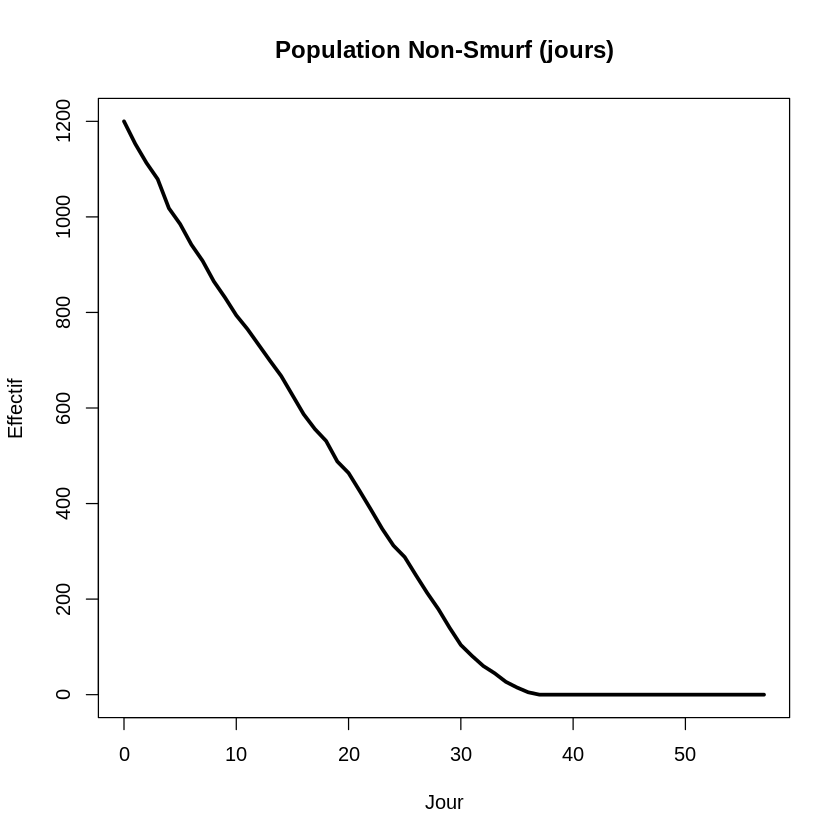

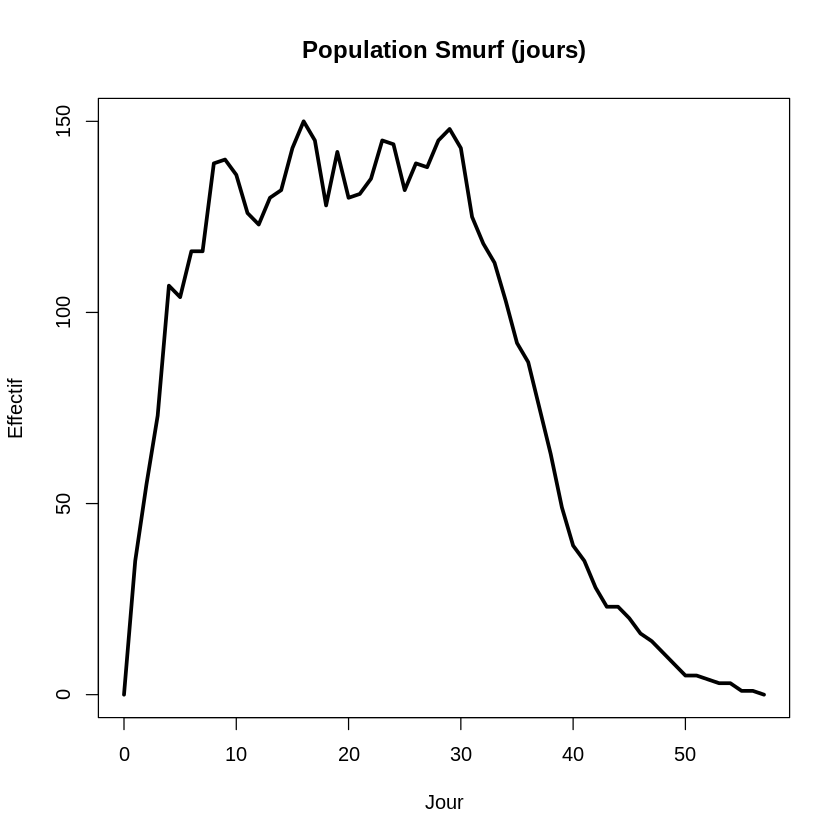

,Fly,T_NS,T_S,T_DEATH
,<int>,<dbl>,<dbl>,<dbl>
1,1,7.935566,0.8383558,8.773922
2,2,1.757718,1.4462650,3.203983
3,3,28.807330,0.2070730,29.014403
4,4,12.647009,8.7117646,21.358773
5,5,8.735182,0.6230135,9.358196
6,6,22.480378,11.3803729,33.860751


,Jour,NonSmurf,Smurf,Dead
,<int>,<dbl>,<dbl>,<dbl>
1,0,1200,0,0
2,1,1153,35,12
3,2,1113,55,32
4,3,1079,73,48
5,4,1018,107,75
6,5,985,104,111


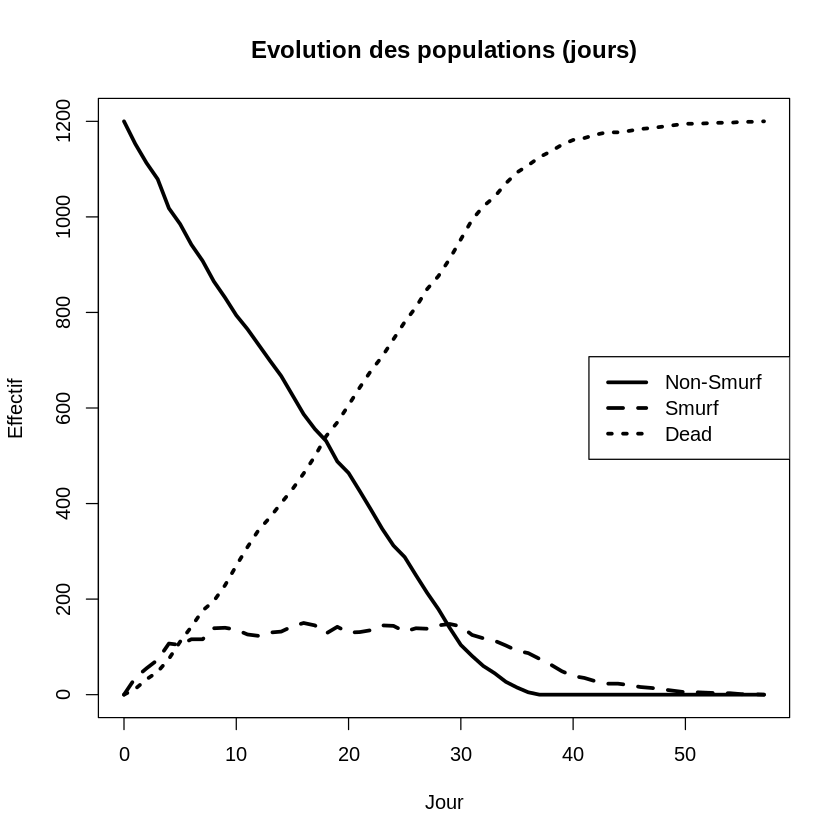

In [ ]:
#################################################
# PARAMETRES
#################################################

N0 <- 1200

# Non-Smurf -> Smurf
F <- 0.00146805570484498
G <- 7.54476439893396e-05
H <- 0.0066373291015625

# Mortalité Smurf
K1 <- 0.0073127348748547
K2 <- 0.0293175232889041
D  <- 0.06715

#################################################
# 1. TEMPS NON-SMURF (EN HEURES)
#################################################

rNonSmurf <- function(n,F,G,H){

  U <- runif(n)

  times <- sapply(U,function(u){

    uniroot(

      function(t){

        F*t +
          (G/H)*(exp(H*t)-1) +
          log(u)

      },

      #--------------- La 2ème méthode pour 208 jours
      #  interval=c(0,5000)
      #---------------

      interval=c(0,100000)

    )$root

  })

  return(times/24)
}

#################################################
# 2. TEMPS SMURF (EN HEURES)
#################################################

rSmurf <- function(n,K1,K2,D){

  U <- runif(n)

  times <- sapply(U,function(u){

    f <- function(a){

      K1*a +
      (K2/D)*(1-exp(-D*a)) +
      log(u)

    }


    uniroot(f,c(0,100000))$root
  })

  return(times/24)

}

#################################################
# 3. SIMULATION COMPLETE (EN JOURS)
#################################################

simuler_populations <- function(
  N0,
  F,G,H,
  K1,K2,D
){

  T_NS <- rNonSmurf(N0,F,G,H)
  T_S  <- rSmurf(N0,K1,K2,D)

  T_DEATH <- T_NS + T_S

  flies <- data.frame(
    Fly = 1:N0,
    T_NS = T_NS,
    T_S = T_S,
    T_DEATH = T_DEATH
  )

  tmax <- ceiling(max(T_DEATH))
  time <- 0:tmax

  N_non_smurf <- numeric(length(time))
  N_smurf     <- numeric(length(time))
  N_dead      <- numeric(length(time))

  for(k in seq_along(time)){

    t <- time[k]

    N_non_smurf[k] <- sum(T_NS > t)

    N_smurf[k] <- sum(
      T_NS <= t &
      T_DEATH > t
    )

    N_dead[k] <- sum(T_DEATH <= t)
  }

  daily_pop <- data.frame(
    Day = time,
    NonSmurf = N_non_smurf,
    Smurf = N_smurf,
    Dead = N_dead
  )

  return(list(
    flies = flies,
    daily_pop = daily_pop,
    time_day = time,
    NonSmurf = N_non_smurf,
    Smurf = N_smurf,
    Dead = N_dead,
    T_NS = T_NS,
    T_S = T_S,
    T_DEATH = T_DEATH
  ))
}


#################################################
# 7. COURBES EN JOURS
#################################################
simuler= simuler_populations(
  N0,
  F,G,H,
  K1,K2,D
)

plot(
  simuler$time_day,
  simuler$NonSmurf,
  type="l",
  lwd=3,
  xlab="Jour",
  ylab="Effectif",
  main="Population Non-Smurf (jours)"
)

plot(
  simuler$time_day,
  simuler$Smurf,
  type="l",
  lwd=3,
  xlab="Jour",
  ylab="Effectif",
  main="Population Smurf (jours)"
)

plot(
  simuler$time_day,
  simuler$NonSmurf,
  type="l",
  lwd=3,
  ylim=c(0,N0),
  xlab="Jour",
  ylab="Effectif",
  main="Evolution des populations (jours)"
)

lines(simuler$time_day, simuler$Smurf, lwd=3, lty=2)
lines(simuler$time_day, simuler$Dead, lwd=3, lty=3)

legend(
  "right",
  legend=c("Non-Smurf","Smurf","Dead"),
  lty=c(1,2,3),
  lwd=3
)

#################################################
# 9. AFFICHAGE
#################################################

head(simuler$flies)
head(data.frame(
  Jour = simuler$time_day,
  NonSmurf = simuler$NonSmurf,
  Smurf = simuler$Smurf,
  Dead = simuler$Dead
))

**Code simulation des données (Newton-Raphson)**

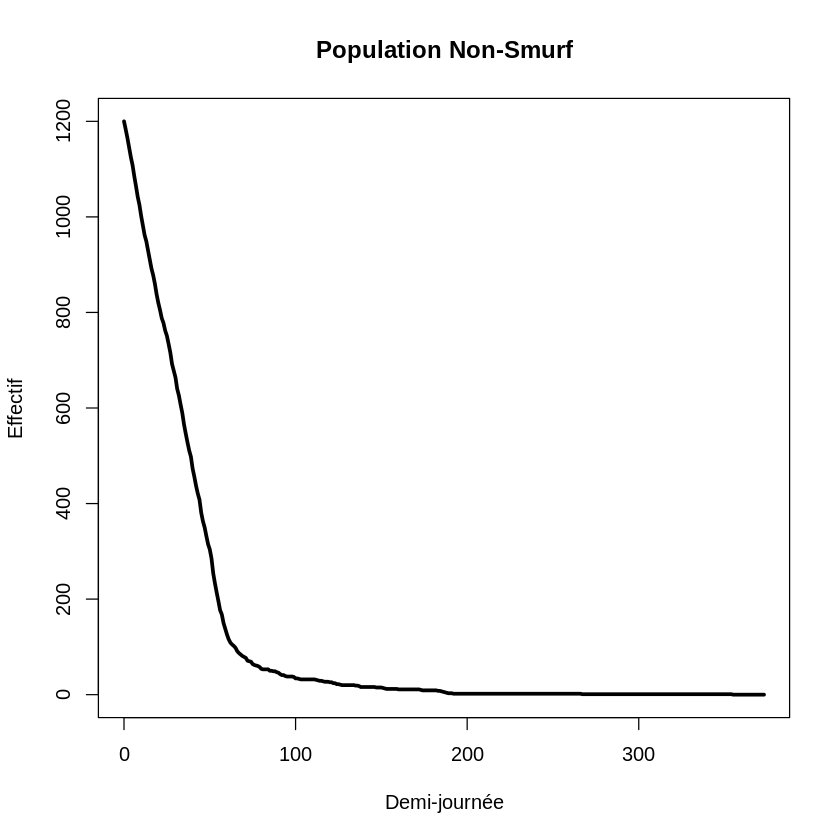

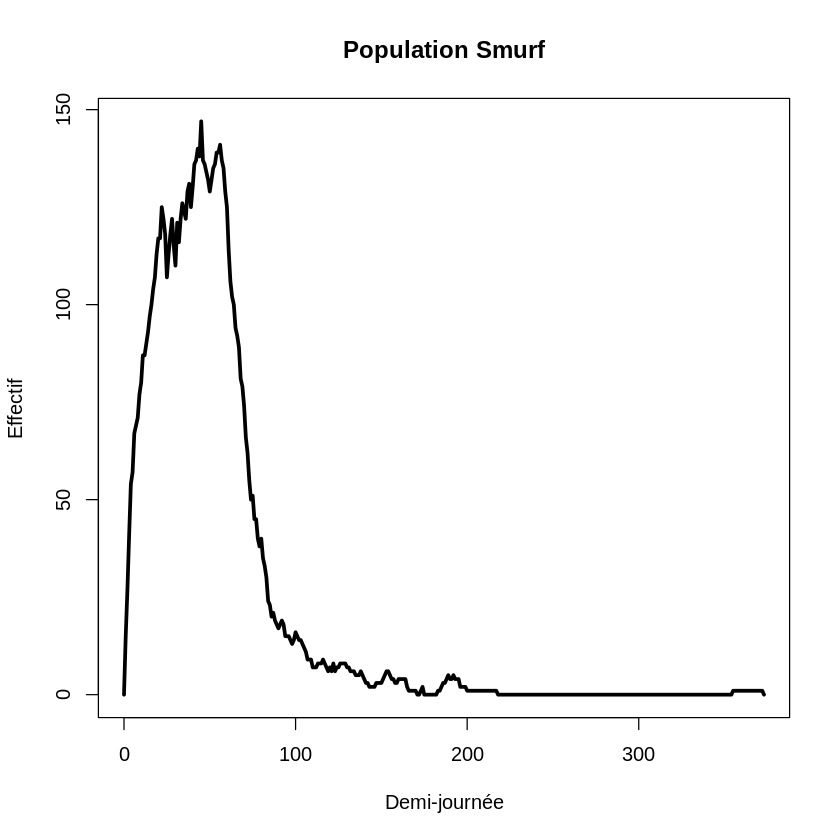

,Fly,T_NS,T_S,T_DEATH
,<int>,<dbl>,<dbl>,<dbl>
1,1,65.42631,52.4321656,117.85848
2,2,43.34828,3.3773748,46.72565
3,3,40.31939,1.6502244,41.96962
4,4,40.97626,17.8801909,58.85645
5,5,51.44846,0.3867946,51.83525
6,6,56.49107,3.9423172,60.43339


,DemiJour,NonSmurf,Smurf,Dead
,<int>,<dbl>,<dbl>,<dbl>
1,0,1200,0,0
2,1,1183,15,2
3,2,1165,27,8
4,3,1145,41,14
5,4,1125,54,21
6,5,1108,57,35


===== MOYENNES EN JOURS =====
Non-Smurf : 18.12869 
Smurf     : 3.753967 
Death     : 21.88266 


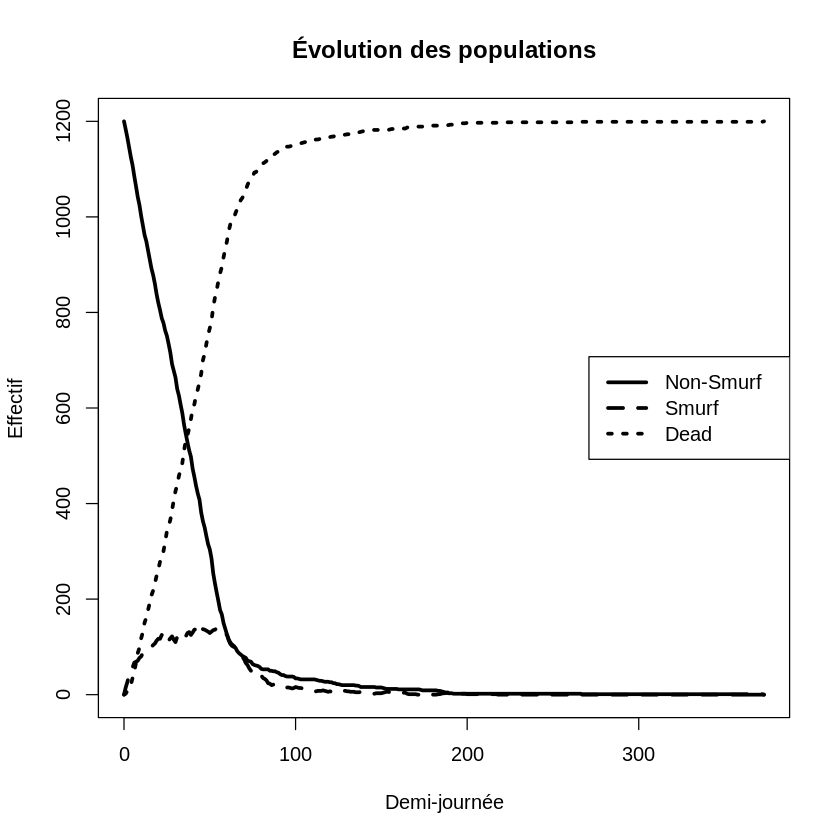

In [ ]:
#################################################
# PARAMETRES
#################################################

N0 <- 1200

# Non-Smurf -> Smurf
F <- 0.00146805570484498
G <- 7.54476439893396e-05
H <- 0.0066373291015625

# Mortalité Smurf
K1 <- 0.0073127348748547
K2 <- 0.0293175232889041
D  <- 0.06715


#################################################
# 1. SOLVEURS NEWTON-RAPHSON
#################################################

solve_NS1 <- function(u, F, G, H){

  f <- function(t){
    F*t + (G/H)*(exp(H*t)-1) + log(u)
  }

  fprime <- function(t){
    F + G*exp(H*t)
  }

  t <- 1

  for(i in 1:8){
    t <- t - f(t)/fprime(t)
    if(t < 0) t <- 0
  }

  return(t)
}


solve_S1 <- function(u, K1, K2, D){

  f <- function(a){
    K1*a + (K2/D)*(1-exp(-D*a)) + log(u)
  }

  fprime <- function(a){
    K1 + K2*exp(-D*a)
  }

  a <- 1

  for(i in 1:8){
    a <- a - f(a)/fprime(a)
    if(a < 0) a <- 0
  }

  return(a)
}


#################################################
# 2. TEMPS NON-SMURF (DEMI-JOURNÉES)
#################################################

rNonSmurf1 <- function(n, F, G, H){

  U <- runif(n)
  times <- numeric(n)

  for(i in 1:n){
    times[i] <- solve_NS1(U[i], F, G, H)
  }

  return(times / 12)
}


#################################################
# 3. TEMPS SMURF (DEMI-JOURNÉES)
#################################################

rSmurf1 <- function(n, K1, K2, D){

  U <- runif(n)
  times <- numeric(n)

  for(i in 1:n){
    times[i] <- solve_S1(U[i], K1, K2, D)
  }

  return(times / 12)
}


#################################################
# 4. SIMULATION COMPLETE
#################################################

simuler_populations <- function(N0, F,G,H, K1,K2,D){

  T_NS <- rNonSmurf1(N0, F, G, H)
  T_S  <- rSmurf1(N0, K1, K2, D)

  T_DEATH <- T_NS + T_S

  flies <- data.frame(
    Fly = 1:N0,
    T_NS = T_NS,
    T_S = T_S,
    T_DEATH = T_DEATH
  )

  tmax <- ceiling(max(T_DEATH))
  time <- 0:tmax

  N_non_smurf <- numeric(length(time))
  N_smurf <- numeric(length(time))
  N_dead <- numeric(length(time))

  for(k in seq_along(time)){

    t <- time[k]

    N_non_smurf[k] <- sum(T_NS > t)

    N_smurf[k] <- sum(T_NS <= t & T_DEATH > t)

    N_dead[k] <- sum(T_DEATH <= t)
  }

  list(
    flies = flies,
    time = time,
    NonSmurf = N_non_smurf,
    Smurf = N_smurf,
    Dead = N_dead
  )
}


#################################################
# 5. EXECUTION
#################################################

simuler <- simuler_populations(
  N0,
  F,G,H,
  K1,K2,D
)


#################################################
# 6. COURBES (DEMI-JOURNÉES)
#################################################

plot(
  simuler$time,
  simuler$NonSmurf,
  type="l",
  lwd=3,
  xlab="Demi-journée",
  ylab="Effectif",
  main="Population Non-Smurf"
)

plot(
  simuler$time,
  simuler$Smurf,
  type="l",
  lwd=3,
  xlab="Demi-journée",
  ylab="Effectif",
  main="Population Smurf"
)

plot(
  simuler$time,
  simuler$NonSmurf,
  type="l",
  lwd=3,
  ylim=c(0,N0),
  xlab="Demi-journée",
  ylab="Effectif",
  main="Évolution des populations"
)

lines(simuler$time, simuler$Smurf, lwd=3, lty=2)
lines(simuler$time, simuler$Dead, lwd=3, lty=3)

legend(
  "right",
  legend=c("Non-Smurf","Smurf","Dead"),
  lty=c(1,2,3),
  lwd=3
)


#################################################
# 7. AFFICHAGE
#################################################

head(simuler$flies)

head(data.frame(
  DemiJour = simuler$time,
  NonSmurf = simuler$NonSmurf,
  Smurf = simuler$Smurf,
  Dead = simuler$Dead
))

#################################################
# 8. MOYENNES DES TEMPS (EN JOURS)
#################################################

T_NS_jours <- simuler$flies$T_NS / 2
T_S_jours <- simuler$flies$T_S / 2
T_DEATH_jours <- simuler$flies$T_DEATH / 2

cat("===== MOYENNES EN JOURS =====\n")

cat("Non-Smurf :", mean(T_NS_jours), "\n")
cat("Smurf     :", mean(T_S_jours), "\n")
cat("Death     :", mean(T_DEATH_jours), "\n")

**Code simulation (méthode IBPM)**

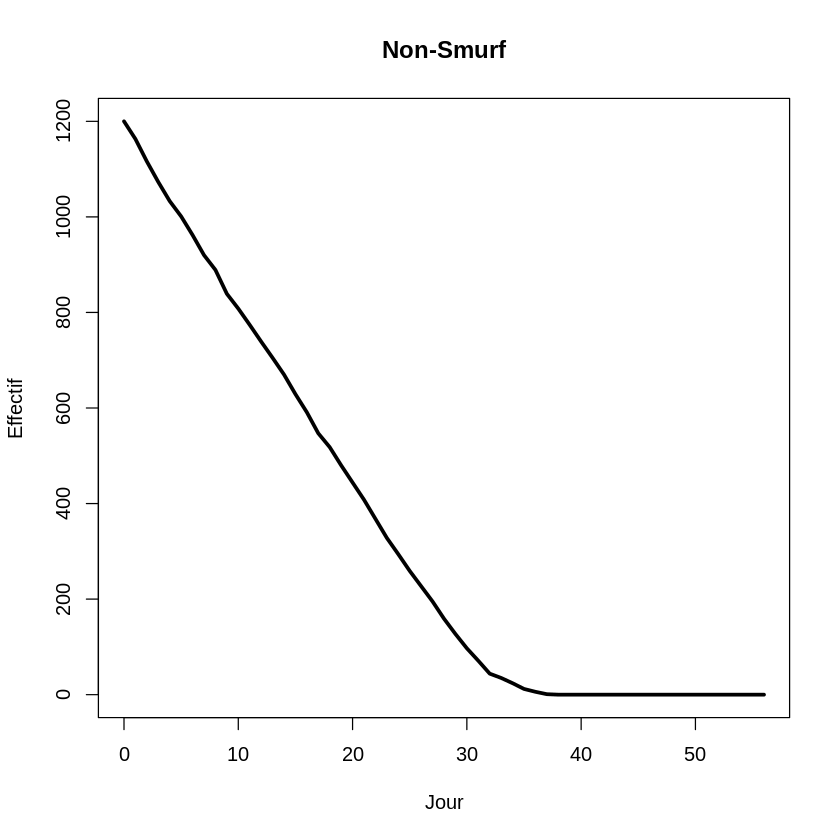

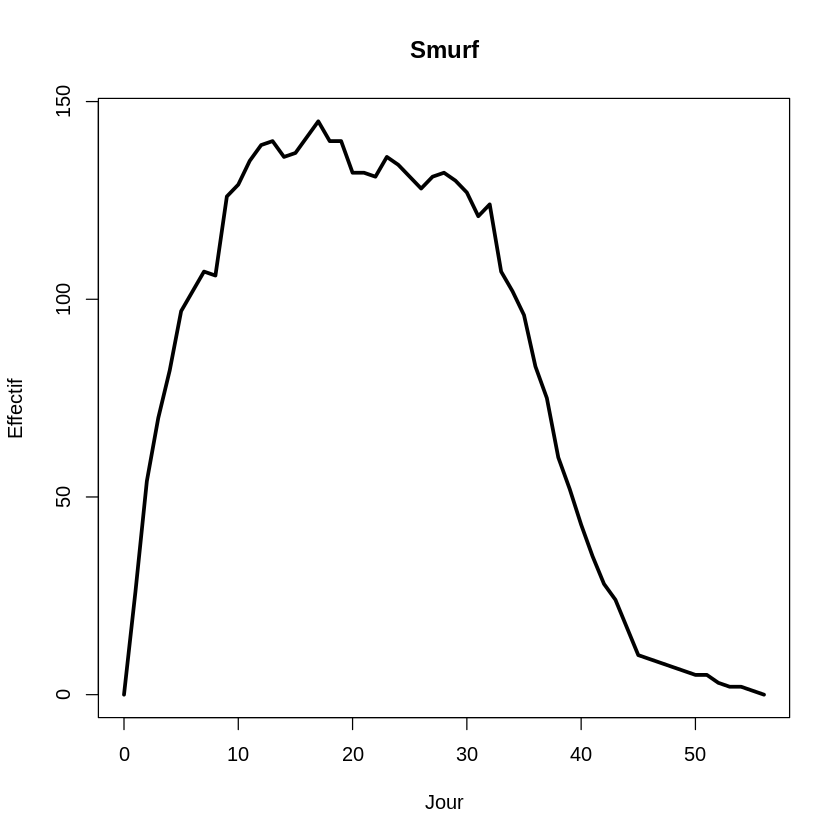

[1] 20.943142 31.985211 28.713836  5.478584  8.182501  5.349951

[1] 0.09722331 0.71883156 2.98865074 0.27010074 3.66856545 0.17983821

[1] 21.040366 32.704043 31.702487  5.748685 11.851066  5.529790

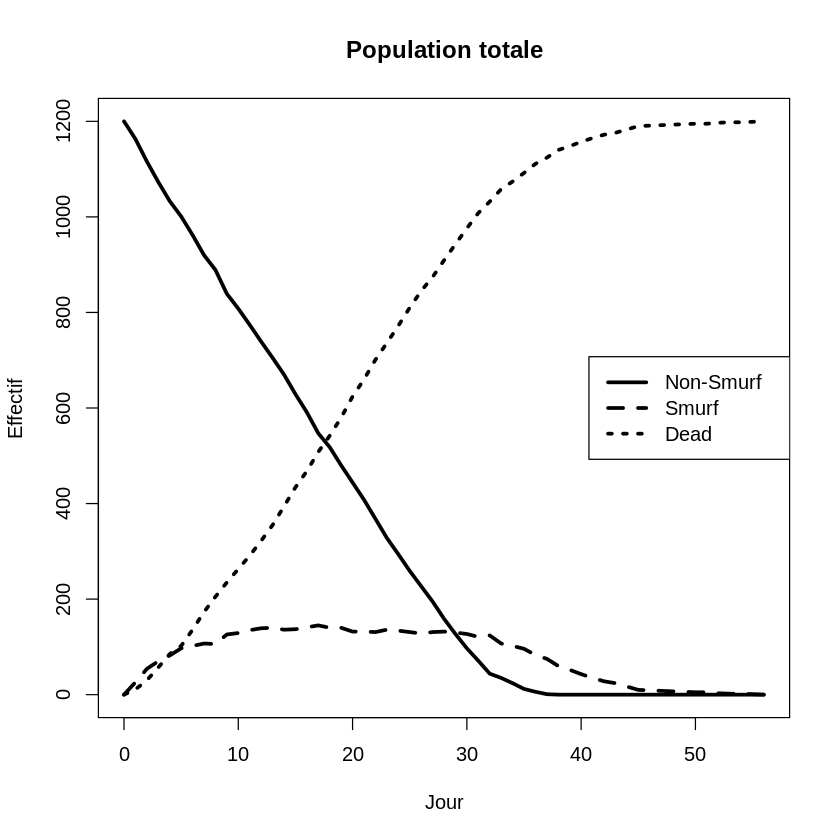

In [ ]:
#################################################
# 0. INITIALISATION
#################################################

rm(list = ls())

#################################################
# 1. MODELE GLOBAL
#################################################

create_model <- function(N0){
  list(N0 = N0)
}

#################################################
# 2. SOLVEUR OPTIMISE
#################################################

solve_times <- function(U, f, interval=c(0,100000)){

  vapply(U, function(u){
    uniroot(function(t) f(t) + log(u), interval)$root
  }, numeric(1))

}

#################################################
# 3. LOI NON-SMURF
#################################################

rNonSmurf <- function(n, F, G, H){

  U <- runif(n)

  f <- function(t){
    F*t + (G/H)*(exp(H*t) - 1)
  }

  solve_times(U, f) / 24    #/12 pour une prise de donnée sur 12 heures
}

#################################################
# 4. LOI SMURF
#################################################

rSmurf <- function(n, K1, K2, D){

  U <- runif(n)

  f <- function(t){
    K1*t + (K2/D)*(1 - exp(-D*t))
  }

  solve_times(U, f) / 24    #/12 pour une prise de donnée sur 12 heures
}

#################################################
# 5. SIMULATION COMPLETE
#################################################

simulate_system <- function(model, params){

  N0 <- model$N0

  F  <- params["F"]
  G  <- params["G"]
  H  <- params["H"]

  K1 <- params["K1"]
  K2 <- params["K2"]
  D  <- params["D"]

  # générations des temps individuels
  T_NS <- rNonSmurf(N0, F, G, H)
  T_S  <- rSmurf(N0, K1, K2, D)

  T_DEATH <- T_NS + T_S

  # grille temporelle
  tmax <- ceiling(max(T_DEATH))
  time <- 0:tmax

  # populations
  NonSmurf <- vapply(time, function(t) sum(T_NS > t), numeric(1))
  Smurf    <- vapply(time, function(t) sum(T_NS <= t & T_DEATH > t), numeric(1))
  Dead     <- vapply(time, function(t) sum(T_DEATH <= t), numeric(1))

  list(
    time = time,
    NonSmurf = NonSmurf,
    Smurf = Smurf,
    Dead = Dead,
    raw = list(T_NS=T_NS, T_S=T_S, T_DEATH=T_DEATH)
  )
}

#################################################
# 6. CACHE
#################################################

cache <- new.env()

simulate_cached <- function(model, params){

  key <- paste(round(params, 6), collapse = "_")

  if(exists(key, cache)){
    return(cache[[key]])
  }

  res <- simulate_system(model, params)
  cache[[key]] <- res

  res
}

#################################################
# 7. WRAPPER ABC
#################################################

abc_step <- function(model, params){
  simulate_cached(model, params)
}

#################################################
# 8. PARAMETRES DE TEST
#################################################

N0 <- 1200

params <- c(
  F  = 0.00146805570484498,
  G  = 7.54476439893396e-05,
  H  = 0.0066373291015625,
  K1 = 0.0073127348748547,
  K2 = 0.0293175232889041,
  D  = 0.06715
)

#################################################
# 9. EXECUTION SIMULATION
#################################################

model <- create_model(N0)

sim <- simulate_system(model, params)

#################################################
# 10. PLOTS
#################################################

plot(sim$time, sim$NonSmurf,
     type="l", lwd=3,
     xlab="Jour", ylab="Effectif",
     main="Non-Smurf")

plot(sim$time, sim$Smurf,
     type="l", lwd=3,
     xlab="Jour", ylab="Effectif",
     main="Smurf")

plot(sim$time, sim$NonSmurf,
     type="l", lwd=3,
     ylim=c(0, N0),
     xlab="Jour", ylab="Effectif",
     main="Population totale")

lines(sim$time, sim$Smurf, lwd=3, lty=2)
lines(sim$time, sim$Dead, lwd=3, lty=3)

legend("right",
       legend=c("Non-Smurf","Smurf","Dead"),
       lty=c(1,2,3),
       lwd=3)

#################################################
# 11. OUTPUT DATA
#################################################

head(sim$raw$T_NS)
head(sim$raw$T_S)
head(sim$raw$T_DEATH)

In [ ]:
#################################################
# VERIFICATION NON-SMURF
#################################################

png("verification_non_smurf.png", width=800, height=600)

plot(
  ecdf(simuler$T_NS),
  main = "Fonction de répartition Non-Smurf",
  xlab = "Temps (jours)",
  ylab = "F(t)",
  lwd = 3,
  col = "blue"
)

F_NS <- function(t){

  1 - exp(
    -F*(24*t) -
    (G/H)*(exp(H*(24*t))-1)
  )

}

x <- seq(
  0,
  max(simuler$T_NS),
  length.out = 1000
)

lines(
  x,
  F_NS(x),
  lwd = 3,
  lty = 2,
  col = "red"
)

legend(
  "bottomright",
  legend = c("Empirique","Théorique"),
  col = c("blue","red"),
  lwd = 3,
  lty = c(1,2)
)

dev.off()

#################################################
# VERIFICATION SMURF
#################################################


png("verification_smurf.png", width=800, height=600)

plot(
  ecdf(simuler$T_S),
  main = "Fonction de répartition Smurf",
  xlab = "Temps (jours)",
  ylab = "F(t)",
  lwd = 3,
  col = "blue"
)

F_S <- function(t){

  a <- 24*t

  1 - exp(
    -K1*a -
    (K2/D)*(1-exp(-D*a))
  )

}

x <- seq(
  0,
  max(simuler$T_S),
  length.out = 1000
)

lines(
  x,
  F_S(x),
  lwd = 3,
  lty = 2,
  col = "red"
)

legend(
  "bottomright",
  legend = c("Empirique","Théorique"),
  col = c("blue","red"),
  lwd = 3,
  lty = c(1,2)
)
dev.off()


agg_record_bd837d0db13 
                     2

agg_record_bd837d0db13 
                     2

res.new chargé avec succès ! 1000 lignes.
Parametres moyens utilises pour les 1000 simulations :
K1_moyen = 0.009042168  K2_moyen = 0.01135178  D_moyen = 0.08869876 


agg_record_bd848ee8562 
                     2

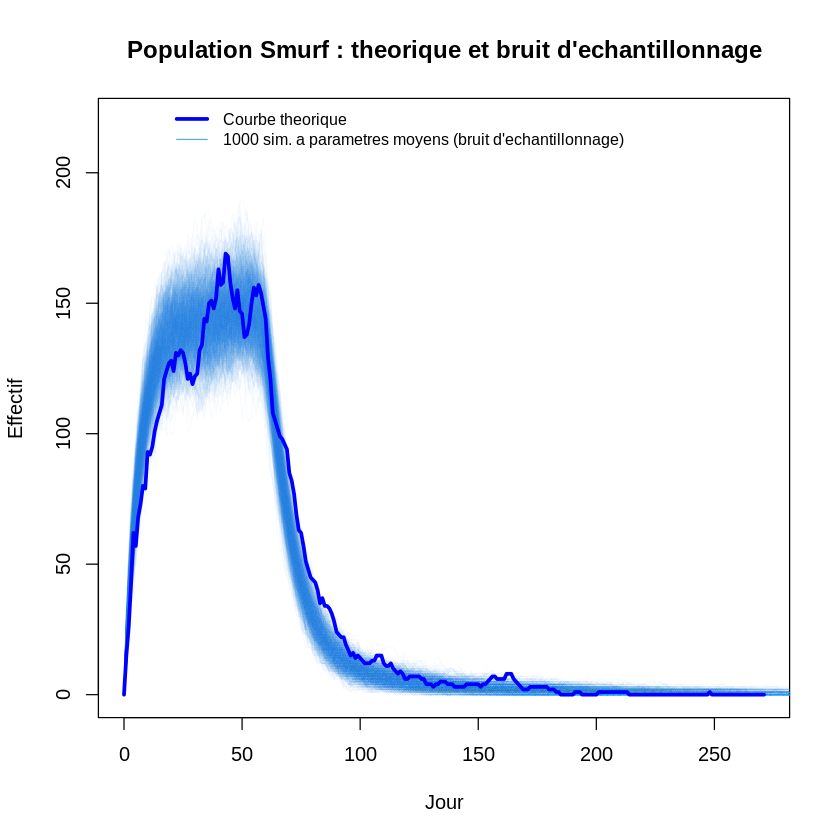

In [ ]:
#################################################################
# POPULATION SMURF : THEORIQUE + 1000 SIMULATIONS
# A PARAMETRES MOYENS (bruit d'echantillonnage pur)
#################################################################


#################################################################
# 0. CHARGEMENT DES PARTICULES DE LA DISTANCE D1
#################################################################

chemin_d1 <- "ABC_SMC_gen_6_k1k2D_réelle.RData"

env_d1 <- new.env()
load(chemin_d1, envir = env_d1)
res.new <- env_d1$res.new

# Conversion forcée en matrice numérique (pour éliminer les facteurs/textes)
res.new <- as.matrix(res.new)
class(res.new) <- "numeric"

# Si votre objet contenait des noms de colonnes ou d'autres objets,
# on s'assure qu'on prend bien uniquement les colonnes K1, K2, D :
cat("res.new chargé avec succès !", nrow(res.new), "lignes.\n")


#################################################################
# 1. PARAMETRES THEORIQUES ET SIMULATEUR INDIVIDUEL (comme Partie I)
#################################################################

N0 <- 1200
F <- 0.00146805570484498
G <- 7.54476439893396e-05
H <- 0.0066373291015625
K1_theo <- 0.0073127348748547
K2_theo <- 0.0293175232889041
D_theo  <- 0.06715

solve_NS1 <- function(u, F, G, H){
  f <- function(t) F*t + (G/H)*(exp(H*t)-1) + log(u)
  fprime <- function(t) F + G*exp(H*t)
  t <- 1
  for(i in 1:8){ t <- t - f(t)/fprime(t); if(t < 0) t <- 0 }
  t
}

solve_S1 <- function(u, K1, K2, D){
  f <- function(a) K1*a + (K2/D)*(1-exp(-D*a)) + log(u)
  fprime <- function(a) K1 + K2*exp(-D*a)
  a <- 1
  for(i in 1:8){ a <- a - f(a)/fprime(a); if(a < 0) a <- 0 }
  a
}

rNonSmurf1 <- function(n, F, G, H){
  U <- runif(n)
  sapply(U, function(u) solve_NS1(u, F, G, H)) / 12   # demi-journees
}

rSmurf1 <- function(n, K1, K2, D){
  U <- runif(n)
  sapply(U, function(u) solve_S1(u, K1, K2, D)) / 12   # demi-journees
}

simuler_populations <- function(N0, F, G, H, K1, K2, D){
  T_NS <- rNonSmurf1(N0, F, G, H)
  T_S  <- rSmurf1(N0, K1, K2, D)
  T_DEATH <- T_NS + T_S

  tmax <- ceiling(max(T_DEATH))
  time <- 0:tmax

  N_non_smurf <- sapply(time, function(t) sum(T_NS > t))
  N_smurf     <- sapply(time, function(t) sum(T_NS <= t & T_DEATH > t))
  N_dead      <- sapply(time, function(t) sum(T_DEATH <= t))

  list(time = time, NonSmurf = N_non_smurf, Smurf = N_smurf, Dead = N_dead)
}


#################################################################
# 2. COURBE THEORIQUE (parametres theoriques, K1,K2,D references)
#################################################################

set.seed(1)
sim_theorique <- simuler_populations(N0, F, G, H, K1_theo, K2_theo, D_theo)


#################################################################
# 3. 1000 SIMULATIONS A PARAMETRES MOYENS (bruit pur)
#    Un seul jeu de parametres (la moyenne des 1000 particules),
#    mais 1000 simulations differentes -> variabilite due
#    UNIQUEMENT a l'echantillonnage stochastique, pas aux parametres.
#################################################################

K1_moyen <- mean(res.new[,1])
K2_moyen <- mean(res.new[,2])
D_moyen  <- mean(res.new[,3])

cat("Parametres moyens utilises pour les 1000 simulations :\n")
cat("K1_moyen =", K1_moyen, " K2_moyen =", K2_moyen, " D_moyen =", D_moyen, "\n")

n_simulations_bruit <- 1000
set.seed(3)
simulations_bruit <- vector("list", n_simulations_bruit)
for(i in 1:n_simulations_bruit){
  simulations_bruit[[i]] <- simuler_populations(N0, F, G, H, K1_moyen, K2_moyen, D_moyen)
}


#################################################################
# 4. GRAPHIQUE : theorique + 1000 simulations (parametres moyens)
#################################################################

tracer_population_smurf <- function(){
  plot(sim_theorique$time, sim_theorique$Smurf, type = "n",
       xlim = range(sim_theorique$time),
       ylim = c(0, max(sim_theorique$Smurf) * 1.3),
       xlab = "Jour", ylab = "Effectif",
       main = "Population Smurf : theorique et bruit d'echantillonnage")

  # 1000 simulations a parametres moyens : bruit d'echantillonnage seul
  for(i in 1:n_simulations_bruit){
    lines(simulations_bruit[[i]]$time, simulations_bruit[[i]]$Smurf,
          col = rgb(0.2, 0.6, 0.9, alpha = 0.03))
  }

  # Courbe theorique (au-dessus, bien visible)
  lines(sim_theorique$time, sim_theorique$Smurf, col = "blue", lwd = 3)

  legend("topright",
         legend = c("Courbe theorique",
                    "1000 sim. a parametres moyens (bruit d'echantillonnage)"),
         col = c("blue", rgb(0.2, 0.6, 0.9, alpha = 0.8)),
         lwd = c(3, 1), bty = "n", cex = 0.8)
}

# Affichage direct dans la console / fenetre graphique
tracer_population_smurf()

# Sauvegarde de l'image au format PNG
png("population_smurf_theorique_bruit.png", width = 900, height = 650)
tracer_population_smurf()
dev.off()

#**Simulation avec l'ABC-SMC**

Nous allons utiliser le code **Code simulation (méthode IBPM)** pour la simulation des populations

In [ ]:
# installation du package nécessaire pour utiliser ABC-SMC
install.packages("tmvtnorm")
library(tmvtnorm)

# 3 fonctions utilisées dans l'ABC-SMC

rK <- function(mean, sigma){
	return(rtmvnorm(1,mean=mean, sigma=sigma, lower=lm.low, upper=lm.upp))
}

H_indicator <- function(x) as.numeric(x>0)

prior.non.zero<-function(par){
	prod(sapply(1:3, function(a) H_indicator(par[a]-lm.low[a])* H_indicator(lm.upp[a]-par[a])))
}

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



**`Pour la première partie` : on fixe d'abord K1,K2,D pour estimer les 3 premiers paramètres F , G , H avec une prise de donnée toute les  24 heures**

In [ ]:
calc_distance_2 <- function(D, D_star){

  n <- max( length(D$NonSmurf) , length(D_star$NonSmurf))


  NS <- c(D$NonSmurf, rep(0, n - length(D$NonSmurf)))
  NS_star <- c(D_star$NonSmurf, rep(0, n - length(D_star$NonSmurf)))


  # Distance
  dist_2 <- sqrt(sum((NS - NS_star)^2))

  return(dist_2)
}

In [ ]:
calc_distance_3 <- function(D, D_star){

  n <- max( length(D$NonSmurf) , length(D_star$NonSmurf))

  # Compléter NonSmurf
  NS <- c(D$NonSmurf, rep(0, n - length(D$NonSmurf)))
  NS_star <- c(D_star$NonSmurf, rep(0, n - length(D_star$NonSmurf)))

  # Compléter Smurf
  S <- c(D$Smurf, rep(0, n - length(D$Smurf)))
  S_star <- c(D_star$Smurf, rep(0, n - length(D_star$Smurf)))

  # Distance
  dist_3 <- sqrt(sum((NS - NS_star)^2)) + sqrt(sum((S - S_star)^2))

  return(dist_3)
}

In [ ]:

##### paramètres théoriques
N0 <- 1200

# Non-Smurf -> Smurf
F_obs <- 0.00146805570484498
G_obs <- 7.54476439893396e-05
H_obs <- 0.0066373291015625

# Mortalité Smurf
K1_obs <- 0.0073127348748547
K2_obs <- 0.0293175232889041
D_obs_par  <- 0.06715

#####


#création du modèle
params_obs = c(F = F_obs , G = G_obs , H = H_obs , K1 = K1_obs , K2 = K2_obs , D = D_obs_par )
model_obs <- create_model(N0)
D_obs <- simulate_cached(model_obs, params_obs)


#Algo ABC-SMC

N = 1000 # nombres de particules
epsilon_A <-   c(2000,1000,900,700,500,350) # tolérance pour la distance d2 par défaut
# à changer en (2000,1000,900,800,700,500) pour la distance d3


# Nb de générations
Gene <- length(epsilon_A)


# nombre de simulation pour chaque paramètres
n <- 1

#  les bornes des priors
lm.low <- c(
  F=F_obs*0.1 ,
  G=G_obs*0.1,
  H=H_obs*0.1
)
lm.upp <- c(
  F=F_obs*1.9 ,
  G=G_obs*1.9,
  H=H_obs*1.9  )




#simuler_populations(F,G,H)

# Matrice vide qui permet de stocker les paramètres
res.old<-matrix(ncol=3,nrow=N)
res.new<-matrix(ncol=3,nrow=N)

# Vecteurs vide pour stocker les poids
w.old<-matrix(ncol=1,nrow=N)
w.new<-matrix(ncol=1,nrow=N)

model <- create_model(N0)

for(g in 1:Gene){


    i<-1
    while(i <= N){ # tant que le nb de particule acceptée est inférieur au N

        if(g==1){
                # loi des distributions priors
            F <- runif(1, min=lm.low[1], max=lm.upp[1])
            G <-runif(1, min=lm.low[2], max=lm.upp[2])
            H <-runif(1, min=lm.low[3], max=lm.upp[3])

        } else {
            #  selection des particules des générations précédentes
            p<-sample(seq(1,N),1,prob=w.old)
            par<- rK(res.old[p,],sigma)
            F <-par[1]
            G <- par[2]
            H <-par[3]

        }
        #  test si le prior est nulle
        if(prior.non.zero(c(F , G , H))) {

                m<-0
                distance <-matrix(ncol=1,nrow=n)

                for(j in 1:n){
                    params = c(F=F, G=G, H=H, K1=K1_obs, K2=K2_obs, D=D_obs_par)
                    D_star <- simulate_cached(model, params)
                    calc.dist<-calc_distance_2(D_obs, D_star)  # la distance est d2 par défaut
                    cat("dist N= ",calc.dist , "\n")
                    distance[j,] <-calc.dist
                    if(calc.dist <= epsilon_A[g] ){
                        m<-m+1
                    }
                }
                if (m>0){
                    # stockage des poids
                    res.new[i,]<-c(F , G , H)
                # Calcule des poids

                w1<-prod(sapply(1:3, function(b) dunif(res.new[i,b], min=lm.low[b], max=lm.upp[b])))
                if(g==1){
                    w2<-1
                } else {
                    w2<-sum(sapply(1:N, function(a) w.old[a]* dtmvnorm(res.new[i,], mean=res.old[a,], sigma=sigma, lower=lm.low, upper=lm.upp)))
                }
                w.new[i] <- (m/n)*w1/w2

                i <- i+1
                print(paste0('Generation: ', g, ", particle: ", i))
                }
            }
        }

        sigma <- cov(res.new)
        res.old<-res.new
    w.old<-w.new/sum(w.new)
}
colnames(res.new) = c("F" , "G" , "H" )
res.new <- as.data.frame(res.new)

dist N=  541.3346 
[1] "Generation: 1, particle: 2"
dist N=  551.9301 
[1] "Generation: 1, particle: 3"
dist N=  772.6076 
[1] "Generation: 1, particle: 4"
dist N=  298.6298 
[1] "Generation: 1, particle: 5"
dist N=  989.1162 
[1] "Generation: 1, particle: 6"
dist N=  821.9706 
[1] "Generation: 1, particle: 7"
dist N=  2635.62 
[1] "Generation: 1, particle: 8"
dist N=  1145.244 
[1] "Generation: 1, particle: 9"
dist N=  2400.601 
[1] "Generation: 1, particle: 10"
dist N=  1413.699 
[1] "Generation: 1, particle: 11"
dist N=  996.39 
[1] "Generation: 1, particle: 12"
dist N=  1130.267 
[1] "Generation: 1, particle: 13"
dist N=  853.6011 
[1] "Generation: 1, particle: 14"
dist N=  1009.51 
[1] "Generation: 1, particle: 15"
dist N=  1236.624 
[1] "Generation: 1, particle: 16"
dist N=  1287.151 
[1] "Generation: 1, particle: 17"
dist N=  451.5638 
[1] "Generation: 1, particle: 18"
dist N=  1220.82 
[1] "Generation: 1, particle: 19"
dist N=  1772.554 
[1] "Generation: 1, particle: 20"
dist N

**`Deux méthodes` : soit vous resimuler le code ci-dessus avant de lancer les codes pour l'analyse des paramètres acceptés, soit vous importer et charger (load("Nom_du_fichier.Rdata)) le fichier data associé à sa distance qui se trouve dans le Github**

**Analysons les paramètres acceptés et traçons leur histogramme**

In [ ]:
estimated_F = res.new[,1]
estimated_G = res.new[,2]
estimated_H = res.new[,3]




mean_F = mean(estimated_F)
mean_G = mean(estimated_G)
mean_H = mean(estimated_H)


err_F = abs(mean_F - F_obs)/F_obs
err_G = abs(mean_G - G_obs)/G_obs
err_H = abs(mean_H - H_obs)/H_obs




interv_credible_F = quantile(estimated_F, c(0.025,0.975))     #un intervalle de crédibilité à 95 %  de F
interv_credible_G = quantile(estimated_G, c(0.025,0.975))   #un intervalle de crédibilité à 95 %  de G
interv_credible_H = quantile(estimated_H, c(0.025,0.975))     #un intervalle de crédibilité à 95 %  de H

cat("Pour le paramètre F :\n")
cat("  Moyenne des estimations :", round(mean_F, 6), "\n")
cat("  Variance des estimations :", round(var(estimated_F), 9), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_F[1], 6), ", ", round(interv_credible_F[2], 6), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_F[2], 6) - round(interv_credible_F[1], 6), "\n")
cat("  Erreur relative : ", err_F , "\n\n")


cat("Pour le paramètre G :\n")
cat("  Moyenne des estimations :", round(mean_G, 9), "\n")
cat("  Variance des estimations :", round(var(estimated_G), 9), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_G[1], 6), ", ", round(interv_credible_G[2], 6), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_G[2], 6) - round(interv_credible_G[1], 6), "\n")
cat("  Erreur relative : ", err_G , "\n\n")

cat("Pour le paramètre H :\n")
cat("  Moyenne des estimations :", round(mean_H, 6), "\n")
cat("  Variance des estimations :", round(var(estimated_H), 9), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_H[1], 6), ", ", round(interv_credible_H[2], 6), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_H[2], 6) - round(interv_credible_H[1], 6), "\n")
cat("  Erreur relative : ", err_H , "\n\n")



ERROR: Error: object 'res.new' not found


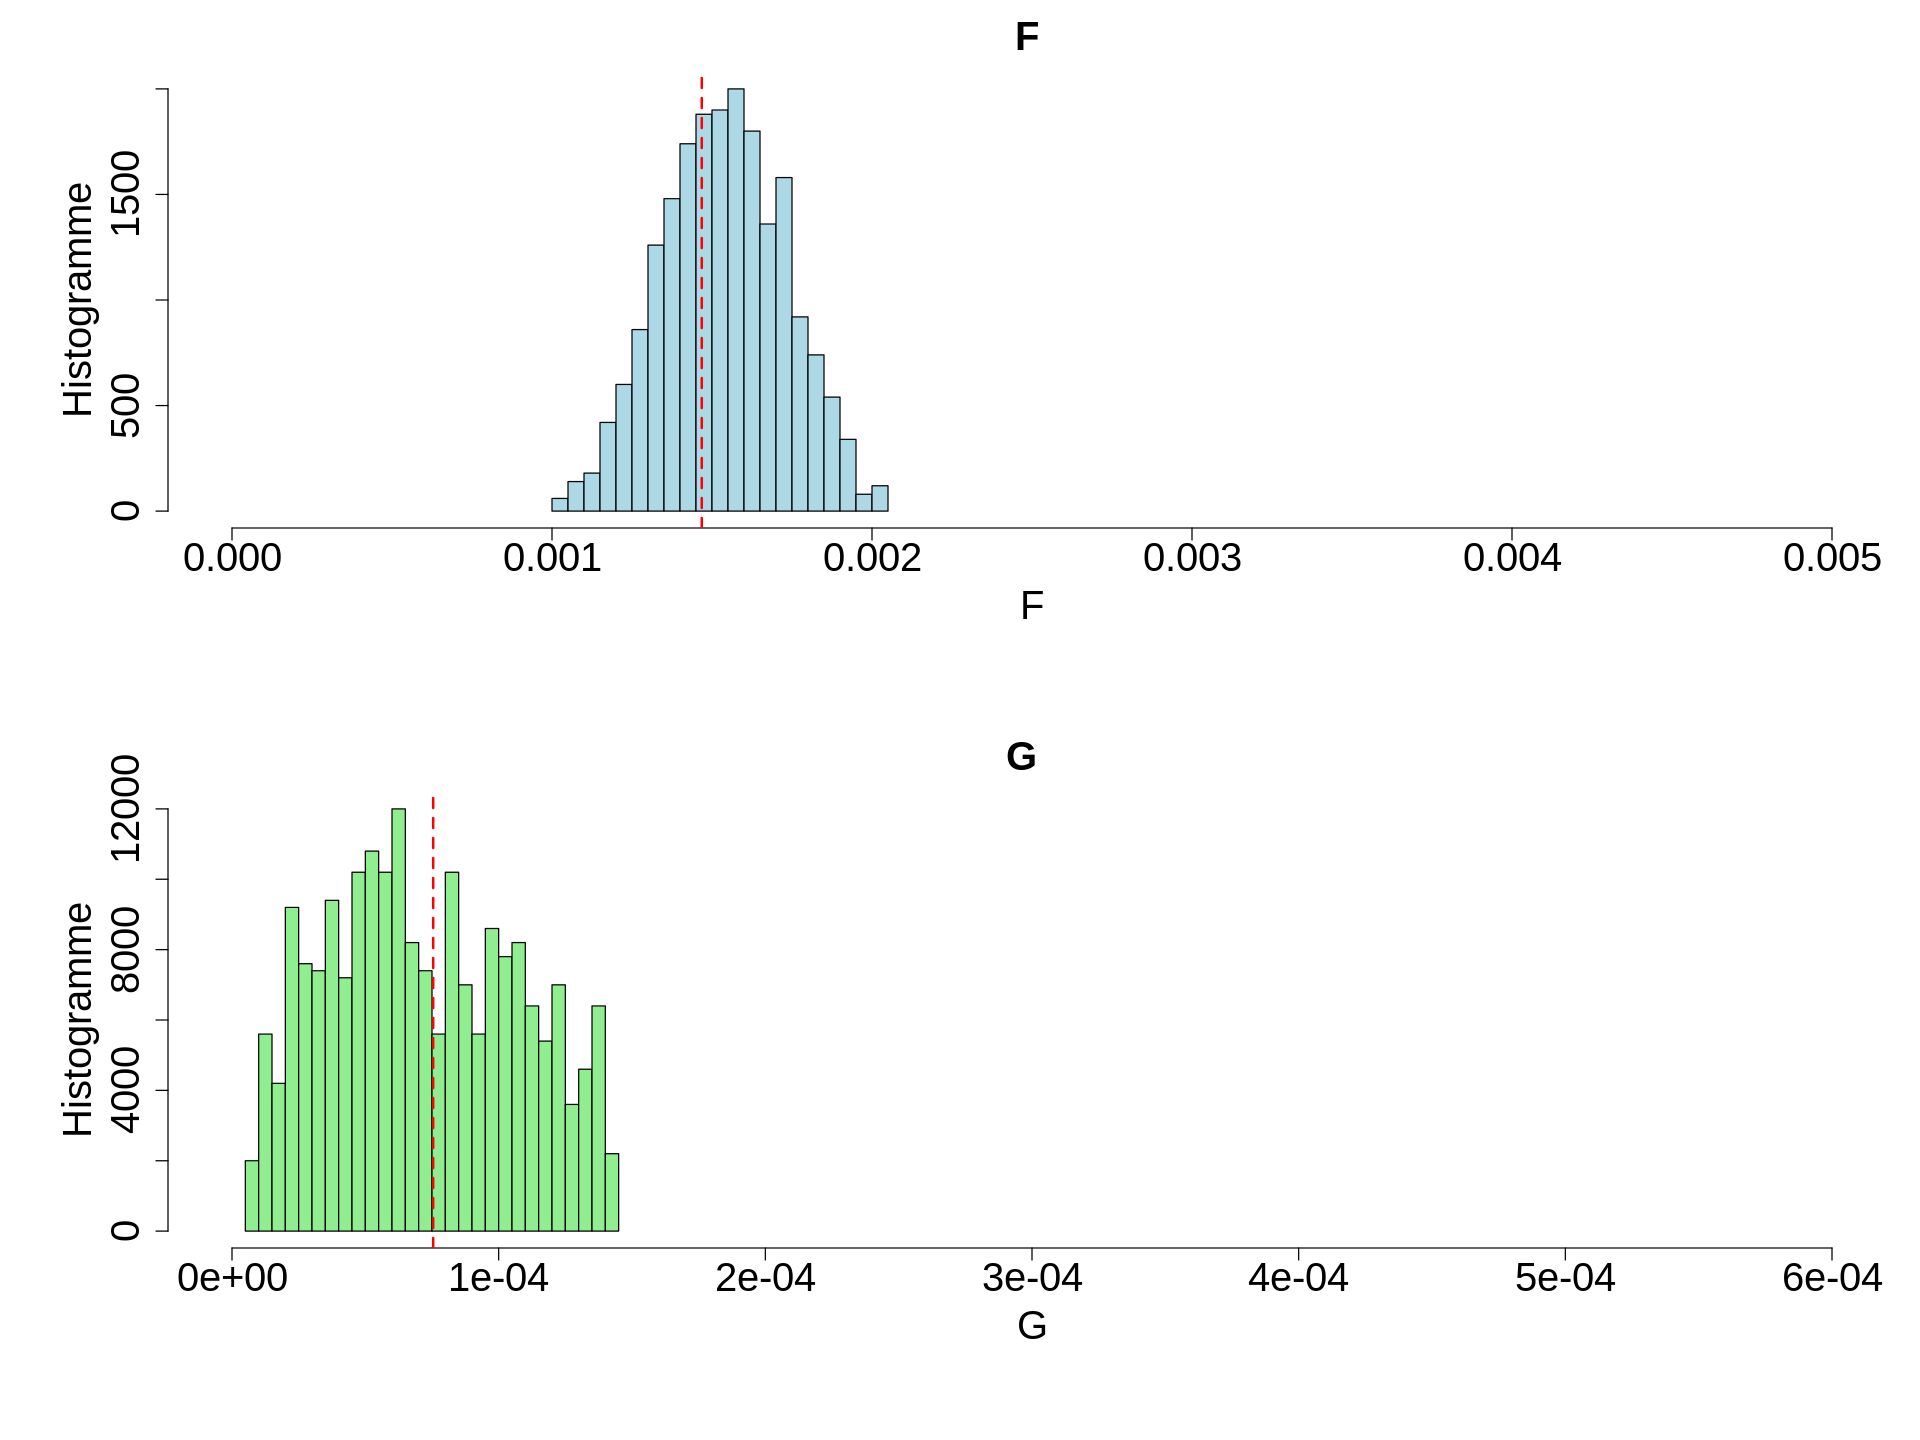

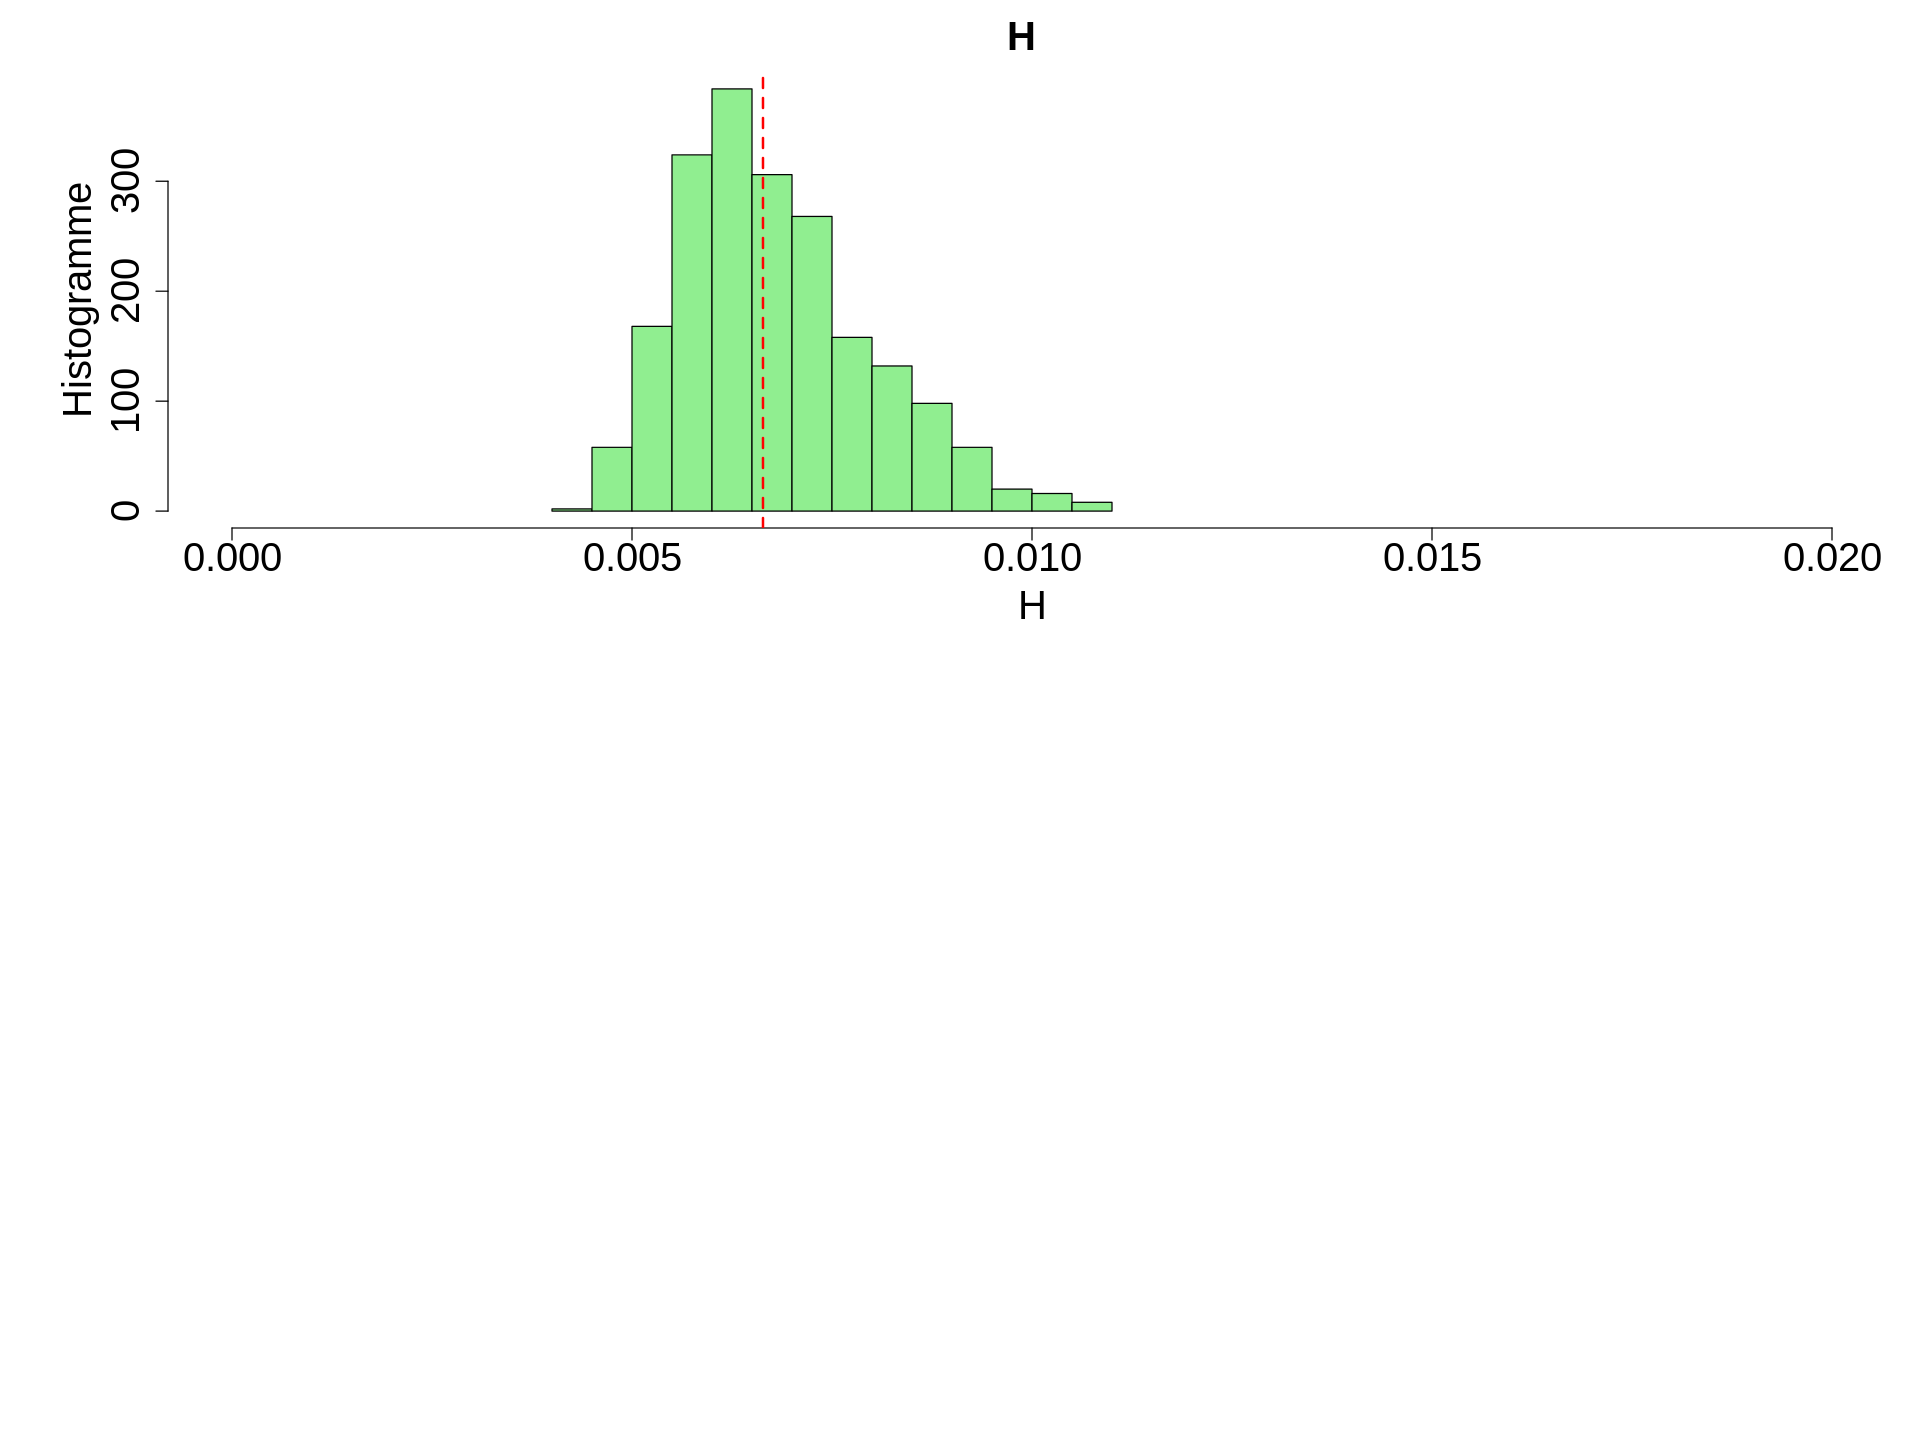

In [ ]:
# ==================================================
# HISTOGRAMMES DES PARAMETRES ACCEPTES
# ==================================================

# Taille des figures
options(
  repr.plot.width = 16,
  repr.plot.height = 12
)

par(mfrow = c(2, 1), mar = c(8, 7, 3, 1)) #permet de diviser la fenêtre en 3 lignes, 1 colonne pour les 3 graphes, and adjusts margins



  # Résultats du cas 1
  res <- res.new



  # =================================================
  # HISTOGRAMME F
  # =================================================

  hist(
    res$F,
    breaks = 20,
    probability = TRUE,
    col = "lightblue",
    main = paste("F "),
    xlab = expression(F),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 0.005)
  )

  abline(
    v = 0.00146805570484498,
    col = "red",
    lwd = 2,
    lty = 2
  )

  # =================================================
  # HISTOGRAMME G
  # =================================================

  hist(
    res$G,
    breaks = 20,
    probability = TRUE,
    col = "lightgreen",
    main = paste( "G  "),
    xlab = expression(G),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 0.0006)
  )

  abline(
    v = 7.54476439893396e-05 ,
    col = "red",
    lwd = 2,
    lty = 2
  )

  # =================================================
  # HISTOGRAMME H
  # =================================================

  hist(
    res$H,
    breaks = 20,
    probability = TRUE,
    col = "lightgreen",
    main = paste( "H  " ),
    xlab = expression(H),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 0.02)
  )

  abline(
    v = 0.0066373291015625 ,
    col = "red",
    lwd = 2,
    lty = 2
  )


**`Pour la deuxième partie` : estimons les paramètres K1,K2,D en fixant F , G , H avec prise de donnée toute les 24 heures**

In [ ]:
calc_distance_1 <- function(D, D_star){

  n <- max(
    length(D$Dead),
    length(D_star$Dead)
  )



  D1 <- c(D$Dead, rep(0, n - length(D$Dead)))
  D1_star <- c(D_star$Dead, rep(0, n - length(D_star$Dead)))

  dist_1 <- sqrt(sum((D1 - D1_star)^2))


  return(dist_1)
}

In [ ]:

##### paramètres théoriques
N0 <- 1200

# Non-Smurf -> Smurf
F_obs <- 0.00146805570484498
G_obs <- 7.54476439893396e-05
H_obs <- 0.0066373291015625

# Mortalité Smurf
K1_obs <- 0.0073127348748547
K2_obs <- 0.0293175232889041
D_obs_par  <- 0.06715

#####


#création du modèle
params_obs = c(F = F_obs , G = G_obs , H = H_obs , K1 = K1_obs , K2 = K2_obs , D = D_obs_par )
model_obs <- create_model(N0)
D_obs <- simulate_cached(model_obs, params_obs)


#Algo ABC-SMC

N = 1000 # nombres de particules
epsilon_A <-   c(9000, 8000 , 6000 ,5000 ,4000,3000)


# Nb de générations
Gene <- length(epsilon_A)


# nombre de simulation pour chaque paramètres
n <- 1

#  les bornes des priors
lm.low <- c(
  K1=K1_obs*0.1 ,
  K2=K2_obs*0.1,
  D=D_obs_par*0.1
)
lm.upp <- c(
  K1=K1_obs*1.9 ,
  K2=K2_obs*1.9,
  D=D_obs_par*1.9  )




#simuler_populations(F,G,H)

# Matrice vide qui permet de stocker les paramètres
res.old<-matrix(ncol=3,nrow=N)
res.new<-matrix(ncol=3,nrow=N)

# Vecteurs vide pour stocker les poids
w.old<-matrix(ncol=1,nrow=N)
w.new<-matrix(ncol=1,nrow=N)

model <- create_model(N0)

for(g in 1:Gene){


    i<-1
    while(i <= N){ # tant que le nb de particule acceptée est inférieur au N

        if(g==1){
                # loi des distributions priors
            K1 <- runif(1, min=lm.low[1], max=lm.upp[1])
            K2 <-runif(1, min=lm.low[2], max=lm.upp[2])
            D <-runif(1, min=lm.low[3], max=lm.upp[3])

        } else {
            #  selection des particules des générations précédentes
            p<-sample(seq(1,N),1,prob=w.old)
            par<- rK(res.old[p,],sigma)
            K1 <-par[1]
            K2 <- par[2]
            D <-par[3]

        }
        #  test si le prior est nulle
        if(prior.non.zero(c(K1 , K2 , D))) {

                m<-0
                distance <-matrix(ncol=1,nrow=n)

                for(j in 1:n){
                    params = c(F=F_obs, G=G_obs, H=H_obs, K1=K1, K2=K2, D=D_obs)
                    D_star <- simulate_cached(model, params)
                    calc.dist<-calc_distance_1(D_obs, D_star)
                    cat("dist N= ",calc.dist , "\n")
                    distance[j,] <-calc.dist
                    if(calc.dist <= epsilon_A[g] ){
                        m<-m+1
                    }
                }
                if (m>0){
                    # stockage des poids
                    res.new[i,]<-c(K1 , K2 , D)
                # Calcule des poids

                w1<-prod(sapply(1:3, function(b) dunif(res.new[i,b], min=lm.low[b], max=lm.upp[b])))
                if(g==1){
                    w2<-1
                } else {
                    w2<-sum(sapply(1:N, function(a) w.old[a]* dtmvnorm(res.new[i,], mean=res.old[a,], sigma=sigma, lower=lm.low, upper=lm.upp)))
                }
                w.new[i] <- (m/n)*w1/w2

                i <- i+1
                print(paste0('Generation: ', g, ", particle: ", i))
                }
            }
        }

        sigma <- cov(res.new)
        res.old<-res.new
    w.old<-w.new/sum(w.new)
}
colnames(res.new) = c("K1" , "K2" , "D" )
res.new <- as.data.frame(res.new)

dist N=  804.8333 
[1] "Generation: 1, particle: 2"
dist N=  395.8739 
[1] "Generation: 1, particle: 3"
dist N=  441.6635 
[1] "Generation: 1, particle: 4"
dist N=  637.6208 
[1] "Generation: 1, particle: 5"
dist N=  277.9107 
[1] "Generation: 1, particle: 6"
dist N=  217.4923 
[1] "Generation: 1, particle: 7"
dist N=  221.3473 
[1] "Generation: 1, particle: 8"
dist N=  283.8401 
[1] "Generation: 1, particle: 9"
dist N=  693.8692 
[1] "Generation: 1, particle: 10"
dist N=  428.1822 
[1] "Generation: 1, particle: 11"
dist N=  488.594 
[1] "Generation: 1, particle: 12"
dist N=  892.5653 
[1] "Generation: 1, particle: 13"
dist N=  240.1569 
[1] "Generation: 1, particle: 14"
dist N=  200.936 
[1] "Generation: 1, particle: 15"
dist N=  585.7901 
[1] "Generation: 1, particle: 16"
dist N=  235.959 
[1] "Generation: 1, particle: 17"
dist N=  222.1363 
[1] "Generation: 1, particle: 18"
dist N=  572.7191 
[1] "Generation: 1, particle: 19"
dist N=  627.3824 
[1] "Generation: 1, particle: 20"
dist

On va refaire le code spécialement pour la distance $d_4$ car il y a deux tolérances

In [ ]:
calc_distance_4 <- function(D, D_star){

  n <- max(
    length(D$Dead),
    length(D_star$Dead)
  )
  D1 <- c(D$Dead, rep(0, n - length(D$Dead)))
  D1_star <- c(D_star$Dead, rep(0, n - length(D_star$Dead)))
  dist_1 <- sqrt(sum((D1 - D1_star)^2))



propor = D$Smurf[17]/(D$Dead[17] + D$Smurf[17])
propor_star = D_star$Smurf[17]/(D_star$Dead[17] + D_star$Smurf[17])

dist_4 = abs(propor - propor_star)



  return(c(dist_1 ,dist_4))
}

In [ ]:
# paramètres théoriques
N0 <- 1200

# Non-Smurf -> Smurf
F_obs <- 0.00146805570484498
G_obs <- 7.54476439893396e-05
H_obs <- 0.0066373291015625

# Mortalité Smurf
K1_obs <- 0.0073127348748547
K2_obs <- 0.0293175232889041
D_obs_par  <- 0.06715


params_obs = c(F = F_obs , G = G_obs , H = H_obs , K1 = K1_obs , K2 = K2_obs , D = D_obs_par )
model_obs <- create_model(N0)
D_obs <- simulate_cached(model_obs, params_obs)


N = 1000 # nb de particule

epsilon_A <-   c(9000 , 8000 , 7000 , 6000 , 5000 , 4000)
epsilon_B <-   c(0.2 , 0.15 , 0.10 , 0.08 , 0.06 , 0.05)

# Nb de génération
Gene <- length(epsilon_A)


# Nb de simulation pour les paramètres
n <- 1

#  borne des priors
lm.low <- c(
  K1=K1_obs*0.1 ,
  K2=K2_obs*0.1,
  D=D_obs_par*0.1
)
lm.upp <- c(
  K1=K1_obs*1.9 ,
  K2=K2_obs*1.9,
  D=D_obs_par*1.9  )


#simuler_populations( N0,F,G,H,K1,K2,D)

# Matrice vide pour stocker les paramètres
res.old<-matrix(ncol=3,nrow=N)
res.new<-matrix(ncol=3,nrow=N)

# Vecteur vide pour stocker les poids
w.old<-matrix(ncol=1,nrow=N)
w.new<-matrix(ncol=1,nrow=N)

model <- create_model(N0)


for(g in 1:Gene){


    i<-1
    while(i <= N){ # tant que le nb de particules acceptées est inférieur à N

        if(g==1){
                # loi des distributions priors
            K1 <- runif(1, min=lm.low[1], max=lm.upp[1])
            K2<- runif(1, min=lm.low[2], max=lm.upp[2])
            D <-runif(1, min=lm.low[3], max=lm.upp[3])
        } else {
            #  selection des particules depuis la génération précédente
            p<-sample(seq(1,N),1,prob=w.old)
            par<- rK(res.old[p,],sigma)
            K1 <-par[1]
            K2 <-par[2]
            D <-par[3]
        }
        #  test si le prior est nulle
        if(prior.non.zero(c( K1 , K2 , D))) {

                m<-0
                distance <-matrix(ncol=2,nrow=n)

                for(j in 1:n){
                    params = c(F=F_obs, G=G_obs, H=H_obs, K1=K1, K2=K2, D=D)
                    D_star <- simulate_cached(model, params)
                    calc.dist<-calc_distance_4(D_obs, D_star)
                    cat("dist N= ",calc.dist , "\n")
                    distance[j,] <-calc.dist
                    if(calc.dist[1] <= epsilon_A[g] & calc.dist[2]<= epsilon_B[g] ){ # si les deux distances sont inferieur à leurs tolérances
                        m<-m+1
                    }
                }
                if (m>0){
                    # stockage des résultats
                    res.new[i,]<-c( K1 , K2 , D)
                # calcul des poids
                w1<-prod(sapply(1:3, function(b) dunif(res.new[i,b], min=lm.low[b], max=lm.upp[b])))
                if(g==1){
                    w2<-1
                } else {
                    w2<-sum(sapply(1:N, function(a) w.old[a]* dtmvnorm(res.new[i,], mean=res.old[a,], sigma=sigma, lower=lm.low, upper=lm.upp)))
                }
                w.new[i] <- (m/n)*w1/w2
                i <- i+1
                print(paste0('Generation: ', g, ", particle: ", i))
                }
            }
        }

        sigma <- cov(res.new)
        res.old<-res.new
    w.old<-w.new/sum(w.new)
}
colnames(res.new) = c( "K1" , "K2" , "D")
res.new <- as.data.frame(res.new)

**Piste envisageable pour diminuer l'erreur de K1** : Pour essayer de diminuer l'erreur relative de K1, on sait que les informations par rapport aux variables aléatoires à estimer sont dans les premières heures alors, on peut se dire qu'au lieu de prélever les données toutes les 24 heures ce que l'on faisait jusqu'à maintenant, on prélève les données toutes les 12 heures (Il faut changer dans le code simulation la /24 par /12).

In [ ]:
calc_distance_1 <- function(D, D_star){

  n <- max(
    length(D$Dead),
    length(D_star$Dead)
  )



  D1 <- c(D$Dead, rep(0, n - length(D$Dead)))
  D1_star <- c(D_star$Dead, rep(0, n - length(D_star$Dead)))

  dist_1 <- sqrt(sum((D1 - D1_star)^2))


  return(dist_1)
}

In [ ]:
# paramètres théoriques
N0 <- 1200

# Non-Smurf -> Smurf
F_obs <- 0.00146805570484498
G_obs <- 7.54476439893396e-05
H_obs <- 0.0066373291015625

# Mortalité Smurf
K1_obs <- 0.0073127348748547
K2_obs <- 0.0293175232889041
D_obs_par  <- 0.06715


D_obs <- simuler_populations(N0 , F_obs , G_obs , H_obs , K1_obs , K2_obs , D_obs_par)


N = 1000

epsilon_A <-   c(10000, 9000 , 8000 ,7000 , 6000 , 5000)

#Nombres de générations
Gene <- length(epsilon_A)


# Nombre de simulation pour les paramètres
n <- 1

# borne des priors
lm.low <- c(
  K1=K1_obs*0.1 ,
  K2=K2_obs*0.1,
  D=D_obs_par*0.1
)
lm.upp <- c(
  K1=K1_obs*1.9 ,
  K2=K2_obs*1.9,
  D=D_obs_par*1.9  )


#simuler_populations( N0,F,G,H,K1,K2,D)

# Matrice vide pour stocker les paramètres
res.old<-matrix(ncol=3,nrow=N)
res.new<-matrix(ncol=3,nrow=N)

# Vecteur vide pour stocker les poids
w.old<-matrix(ncol=1,nrow=N)
w.new<-matrix(ncol=1,nrow=N)



for(g in 1:Gene){

    i<-1
    while(i <= N){ # tant que le nb de particules acceptées est inférieur à N

        if(g==1){
                # loi des distributions priors
            K1 <- runif(1, min=lm.low[1], max=lm.upp[1])
            K2<- runif(1, min=lm.low[2], max=lm.upp[2])
            D <-runif(1, min=lm.low[3], max=lm.upp[3])
        } else {
            #  selection des particules depuis la génération précédente
            p<-sample(seq(1,N),1,prob=w.old)
            par<- rK(res.old[p,],sigma)
            K1 <-par[1]
            K2 <-par[2]
            D <-par[3]
        }
        #  test si le prior est nulle
        if(prior.non.zero(c( K1 , K2 , D))) {
                m<-0
                distance <-matrix(ncol=1,nrow=n)

                for(j in 1:n){
                    D_star <-  simuler_populations(N0 , F_obs , G_obs , H_obs , K1 , K2, D)       # Calculate distances
                    calc.dist<-calc_distance_1(D_obs, D_star)
                    cat("dist N= ",calc.dist , "\n")
                    distance[j,] <-calc.dist
                    if(calc.dist <= epsilon_A[g] ){ # test si la distance est inférieur à la tolérance
                        m<-m+1
                    }
                }
                if (m>0){
                    # stockage des résultats
                    res.new[i,]<-c( K1 , K2 , D)
                # calcul des poids
                w1<-prod(sapply(1:3, function(b) dunif(res.new[i,b], min=lm.low[b], max=lm.upp[b])))  # à modifier de comment on calcul le poids
                if(g==1){
                    w2<-1
                } else {
                    w2<-sum(sapply(1:N, function(a) w.old[a]* dtmvnorm(res.new[i,], mean=res.old[a,], sigma=sigma, lower=lm.low, upper=lm.upp)))
                }
                w.new[i] <- (m/n)*w1/w2
                i <- i+1
                print(paste0('Generation: ', g, ", particle: ", i))
                }
            }
        }

        sigma <- cov(res.new)
        res.old<-res.new
    w.old<-w.new/sum(w.new)
}
colnames(res.new) = c( "K1" , "K2" , "D")
res.new <- as.data.frame(res.new)

**`Deux méthodes` : soit vous resimuler le code ci-dessus avant de lancer les codes pour l'analyse des paramètres acceptés, soit vous importer et charger (load("Nom_du_fichier.Rdata)) le fichier data associé à sa distance qui se trouve dans le Github**

**Analysons les paramètres acceptés et traçons leur histogramme**

In [ ]:
# Mortalité Smurf
K1_obs <- 0.0073127348748547
K2_obs <- 0.0293175232889041
D_obs_par  <- 0.06715



estimated_K1 = res.new[,1]
estimated_K2 = res.new[,2]
estimated_D = res.new[,3]


mean_K1 = mean(estimated_K1)
mean_K2 = mean(estimated_K2)
mean_D = mean(estimated_D)


interv_credible_K1 = quantile(estimated_K1, c(0.025,0.975))     #un intervalle de crédibilité à 95 %  de K1
interv_credible_K2 = quantile(estimated_K2, c(0.025,0.975))   #un intervalle de crédibilité à 95 %  de K2
interv_credible_D = quantile(estimated_D, c(0.025,0.975))     #un intervalle de crédibilité à 95 %  de D

err_K1 = abs(mean_K1 - K1_obs)/K1_obs
err_K2 = abs(mean_K2 - K2_obs)/K2_obs
err_D = abs(mean_D - D_obs_par)/D_obs_par


cat("Pour le paramètre K1 :\n")
cat("  Moyenne des estimations :", round(mean_K1, 6), "\n")
cat("  Variance des estimations :", round(var(estimated_K1), 9), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_K1[1], 6), ", ", round(interv_credible_K1[2], 6), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_K1[2], 6) - round(interv_credible_K1[1], 6), "\n")
cat("  Erreur relative : ", err_K1 , "\n\n")



cat("Pour le paramètre K2 :\n")
cat("  Moyenne des estimations :", round(mean_K2, 9), "\n")
cat("  Variance des estimations :", round(var(estimated_K2), 9), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_K2[1], 6), ", ", round(interv_credible_K2[2], 6), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_K2[2], 6) - round(interv_credible_K2[1], 6), "\n")
cat("  Erreur relative : ", err_K2 , "\n\n")


cat("Pour le paramètre D :\n")
cat("  Moyenne des estimations :", round(mean_D, 6), "\n")
cat("  Variance des estimations :", round(var(estimated_D), 9), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_D[1], 6), ", ", round(interv_credible_D[2], 6), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_D[2], 6) - round(interv_credible_D[1], 6), "\n")
cat("  Erreur relative : ", err_D , "\n\n")


Pour le paramètre K1 :
  Moyenne des estimations : 0.008402 
  Variance des estimations : 3.574e-06 
  Intervalle de crédibilité à 95% : [ 0.004697 ,  0.012093 ]
  Largeur de l'intervalle :  0.007396 

Pour le paramètre K2 :
  Moyenne des estimations : 0.02592061 
  Variance des estimations : 0.000197773 
  Intervalle de crédibilité à 95% : [ 0.004293 ,  0.053293 ]
  Largeur de l'intervalle :  0.049 

Pour le paramètre D :
  Moyenne des estimations : 0.077666 
  Variance des estimations : 0.000842426 
  Intervalle de crédibilité à 95% : [ 0.021338 ,  0.123962 ]
  Largeur de l'intervalle :  0.102624 



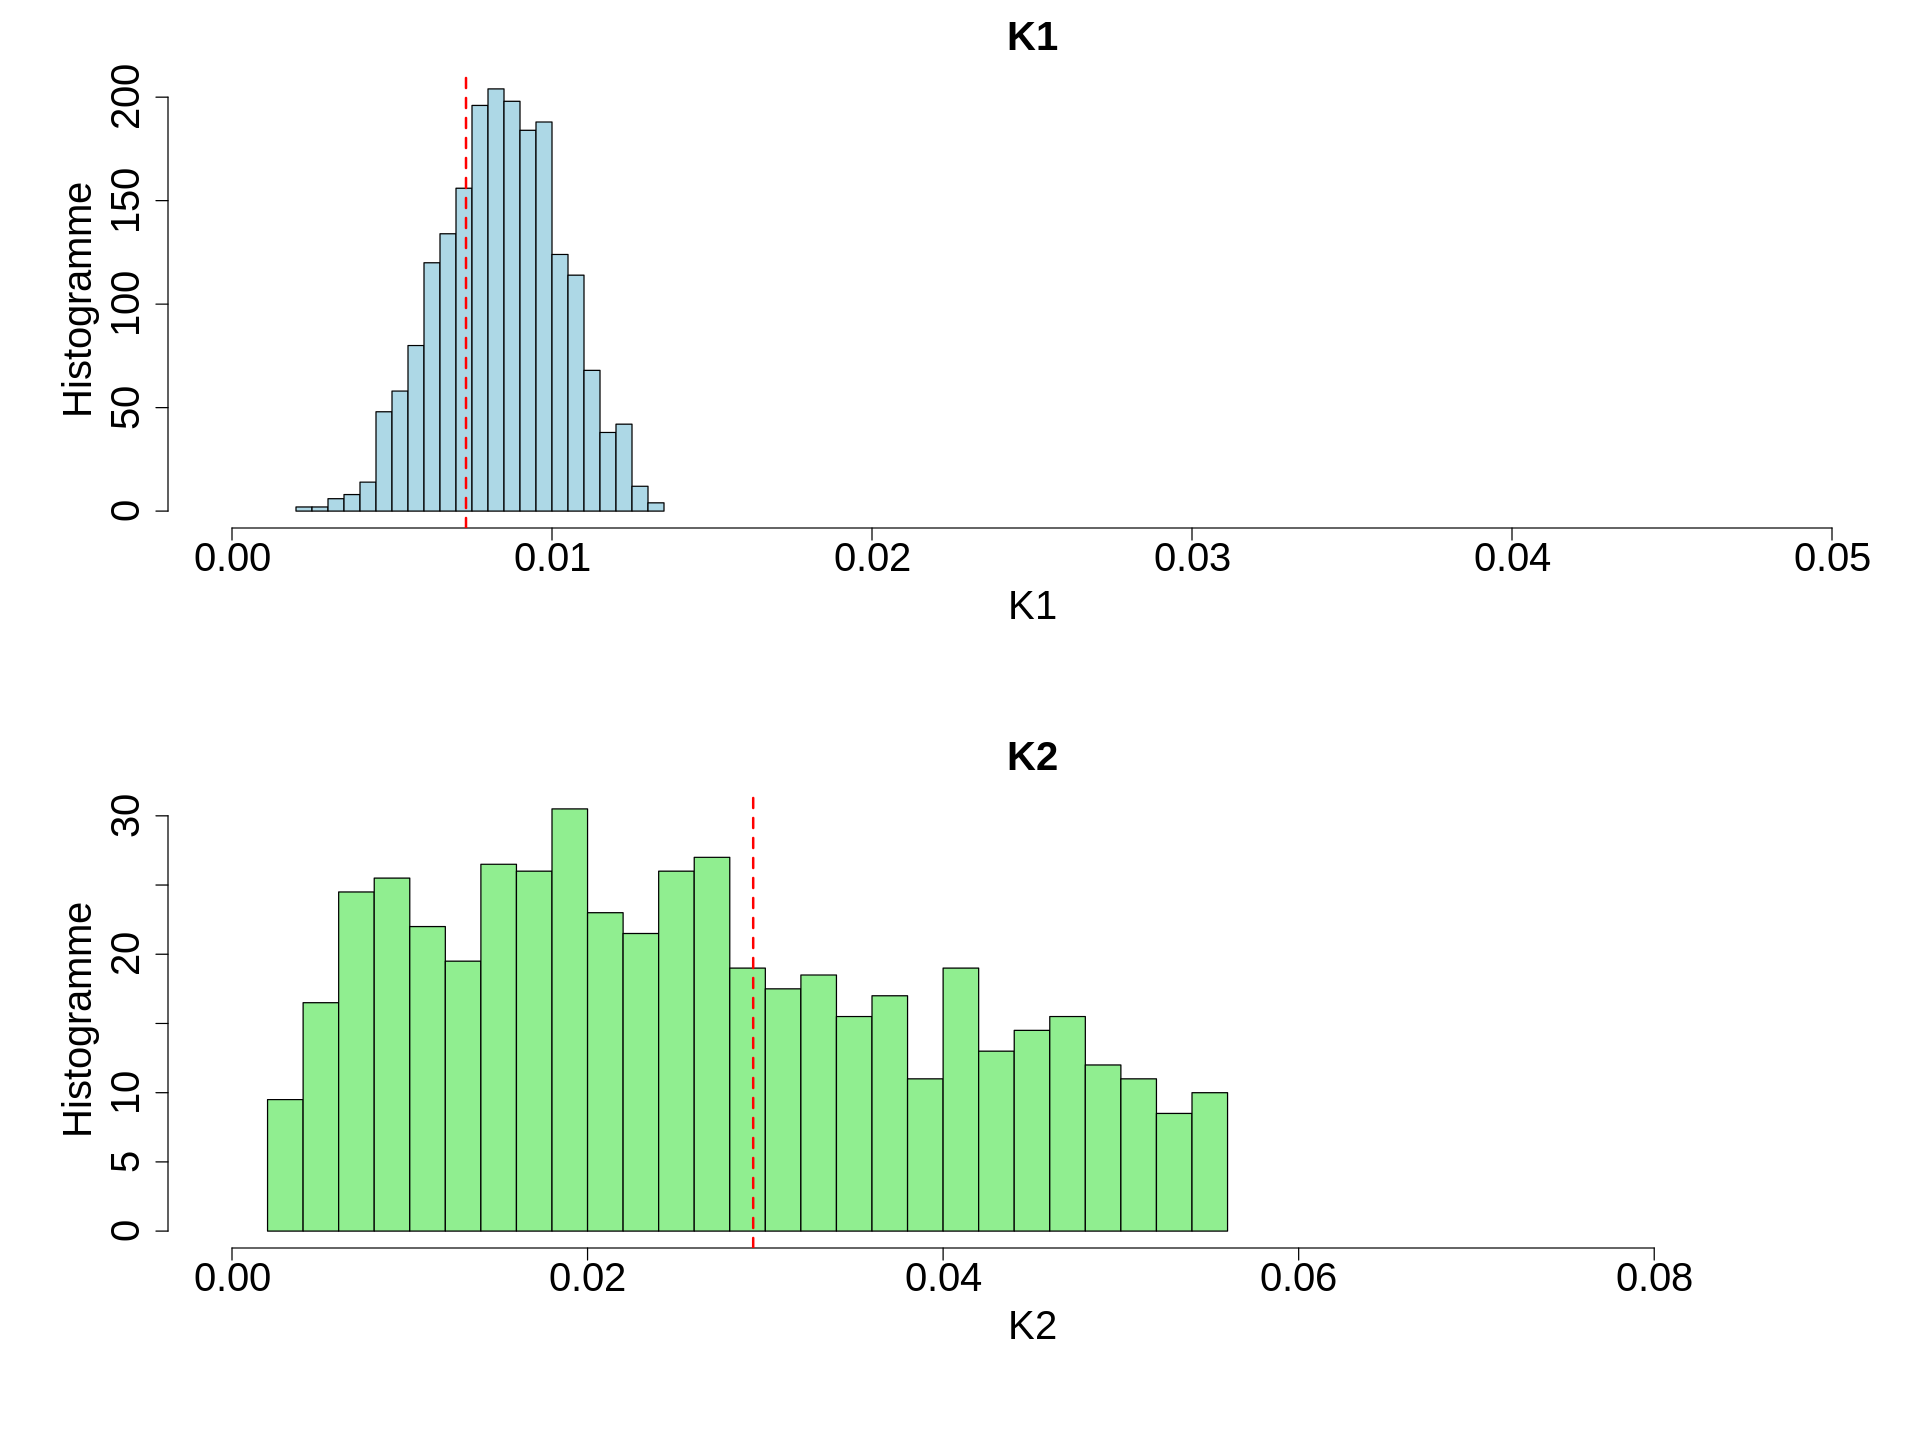

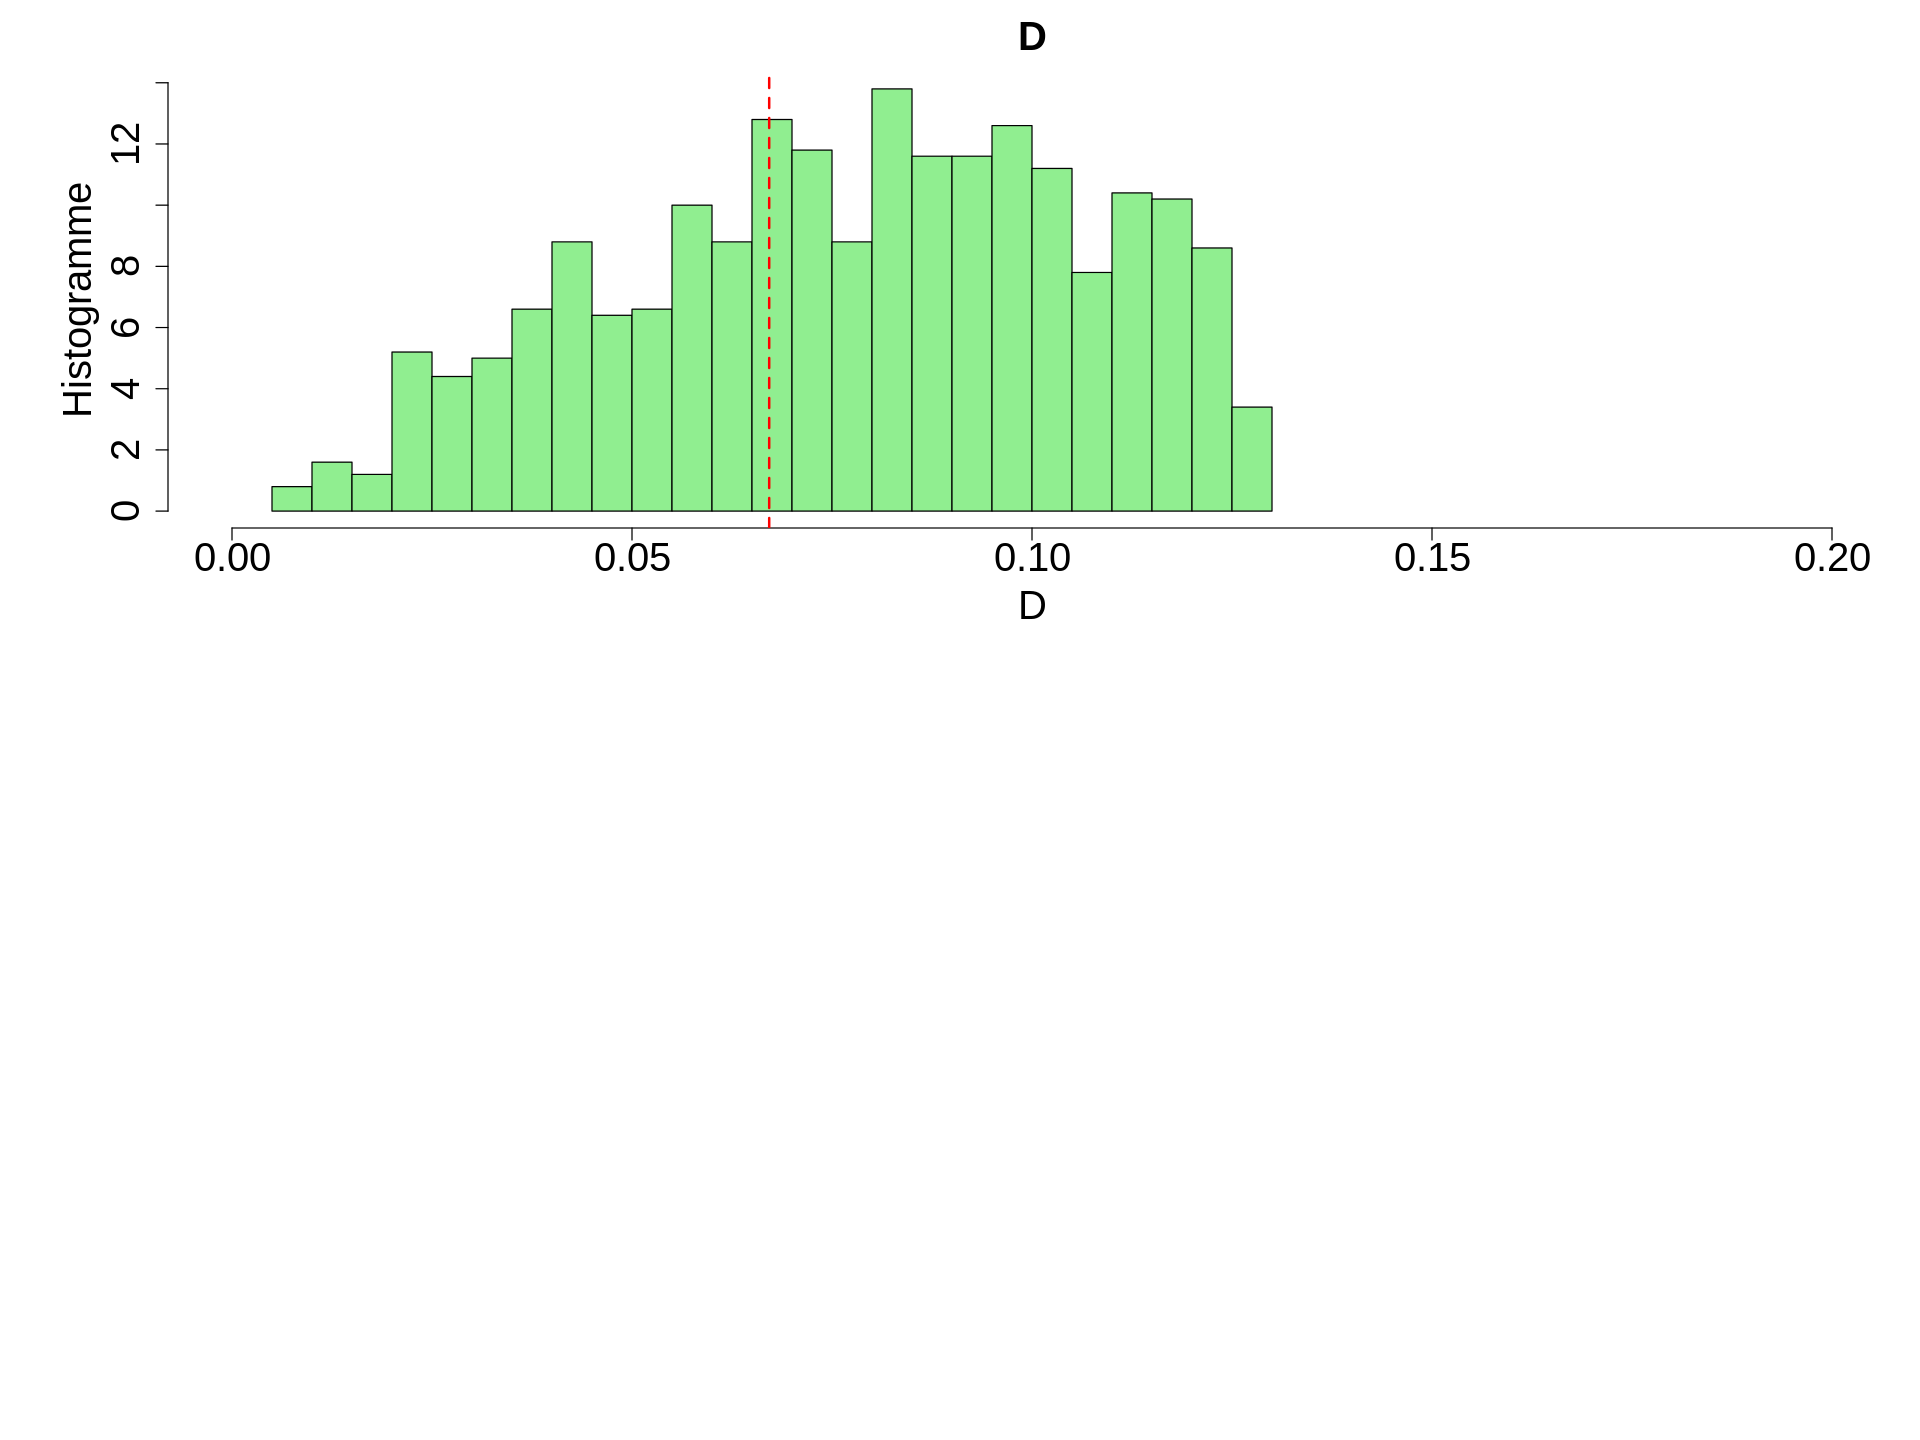

In [ ]:
# ==================================================
# HISTOGRAMMES DES PARAMETRES ACCEPTES
# ==================================================

# Taille des figures
options(
  repr.plot.width = 16,
  repr.plot.height = 12
)

par(mfrow = c(2, 1), mar = c(8, 7, 3, 1)) #permet de diviser la fenêtre en 3 lignes, 1 colonne pour les 3 graphes, and adjusts margins



  # Résultats du cas 1
  res <- res.new



  # =================================================
  # HISTOGRAMME K1
  # =================================================

  hist(
    res[,1],
    breaks = 20,
    probability = TRUE,
    col = "lightblue",
    main = paste("K1"),
    xlab = expression(K1),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 0.05)
  )

  abline(
    v = 0.0073127348748547,
    col = "red",
    lwd = 2,
    lty = 2
  )

  # =================================================
  # HISTOGRAMME K2
  # =================================================

  hist(
    res[,2],
    breaks = 20,
    probability = TRUE,
    col = "lightgreen",
    main = paste( "K2"),
    xlab = expression(K2),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 0.09)
  )

  abline(
    v = 0.0293175232889041 ,
    col = "red",
    lwd = 2,
    lty = 2
  )

  # =================================================
  # HISTOGRAMME D
  # =================================================

  hist(
    res[,3],
    breaks = 20,
    probability = TRUE,
    col = "lightgreen",
    main = paste( "D" ),
    xlab = expression(D),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 0.2)
  )

  abline(
    v = 0.06715 ,
    col = "red",
    lwd = 2,
    lty = 2
  )


#**Partie : Données réelles**

Les données réelles sont dans le fichier times_exp du dossier Data disponible dans le GitHub

Dans un premier temps ce dossier comporte :

- $N_0$ : Nombre de mouche initial
- $\tau_{Smurf}$ : le temps qu'il faut pour qu'une mouche passe de l'état Non-Smurf à Smurf en heures
- $\tau_{Death}$ : le temps qu'il faut pour qu'une mouche décède en étant dans la phase Smurf en heures

Donc nous allons le transformer en nombre de mouche dans la phase Non-Smurf, Smurf et Mort.

La répartition se fera comme suit pour un jour donné t = 1,2,3,...:

- Mouche Non-Smurf $\quad$ si $\quad$ t $\leq \tau_{Smurf}$
- Mouche Smurf $\quad$ si $\quad$ $ \tau_{Smurf}\leq$t $\leq \tau_{Smurf} +  \tau_{Death}$
- Mouche Morte $\quad$ si $\quad$ t $\ge$ $\tau_{Smurf}$ +  $\tau_{Death}$



In [ ]:
# Il faut importer le fichier times_exp dans le répertoir et cette fonction permet de charger les données
df <- read.csv("times_exp.txt")

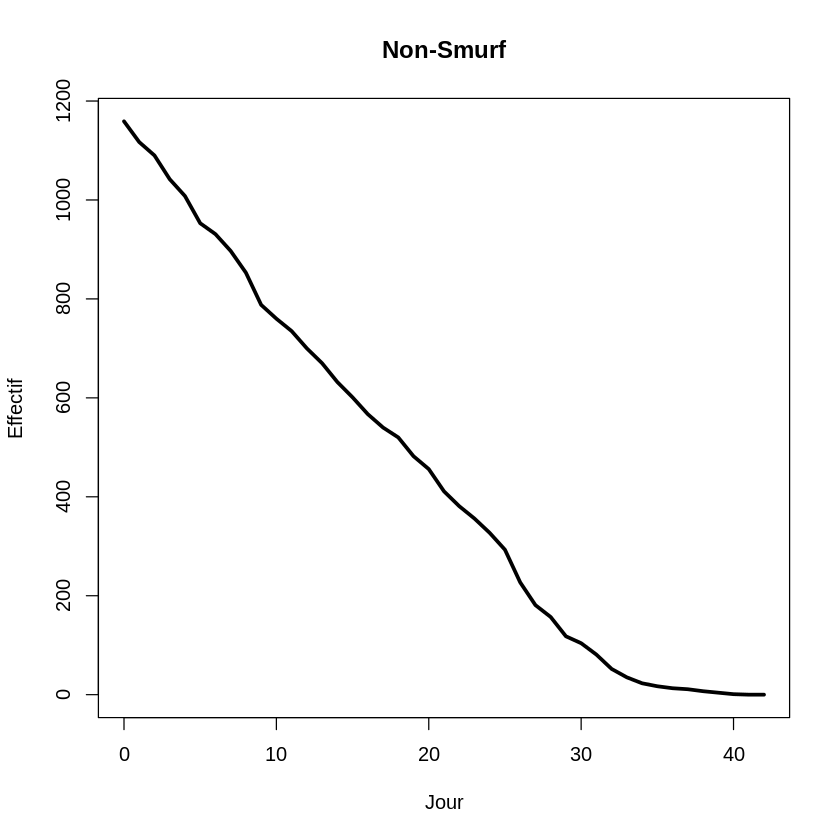

ERROR: Error: object 'N0' not found


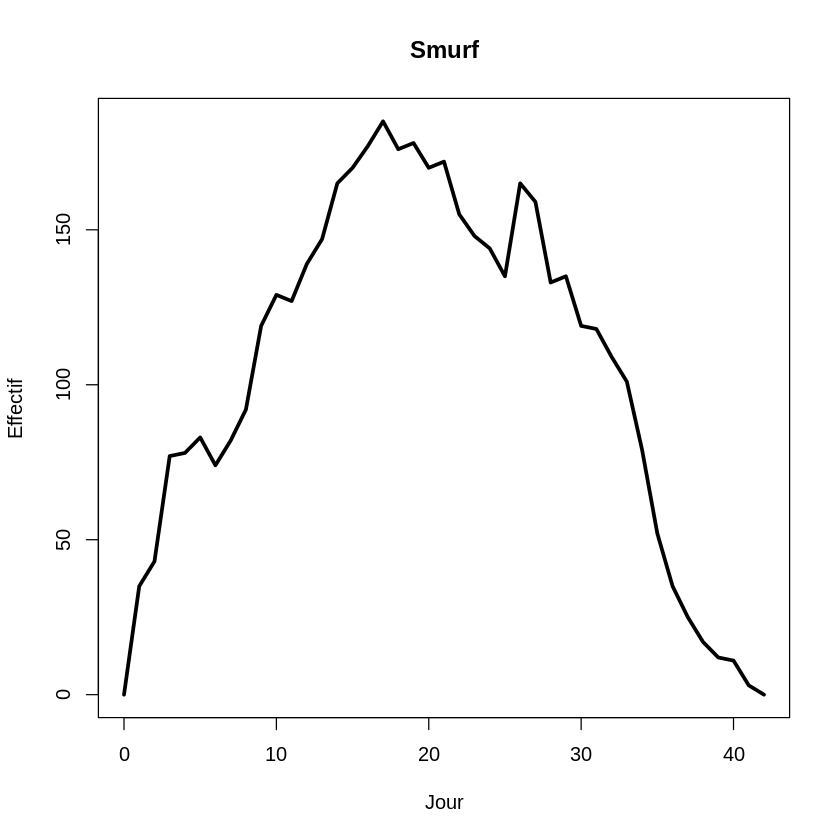

In [ ]:
# --- CONVERSION DES HEURES EN JOURS ---
# On divise par 24 pour que toutes les unités temporelles soient des jours
df$Smurf_days <- df$Smurf / 24
df$Death_days <- df$Death / 24
df$Total_Death_Time_days <- df$Smurf_days + df$Death_days
# --------------------------------------

# 2. Définir la plage de jours à analyser (du jour 0 au jour max arrondi au supérieur)
max_day <- as.integer(ceiling(max(df$Total_Death_Time_days, na.rm = TRUE)))
days <- 0:max_day

# 3. Calculer les effectifs pour chaque jour t
daily_stats_list <- lapply(days, function(t) {
  # NS : le jour t est strictement inférieur au temps de transition Smurf (en jours)
  ns_count <- sum(df$Smurf_days > t, na.rm = TRUE)

  # Smurf : transition faite mais pas encore morte (au jour t)
  smurf_count <- sum(df$Smurf_days <= t & df$Total_Death_Time_days > t, na.rm = TRUE)

  # Mort : le jour t est supérieur ou égal au temps de mort total (en jours)
  death_count <- sum(df$Total_Death_Time_days <= t, na.rm = TRUE)

  data.frame(
    Jour = t,
    NonSmurf = ns_count,
    Smurf = smurf_count,
    Dead = death_count,
    Total_mouches = ns_count + smurf_count + death_count
  )
})

# 4. Fusionner en un seul DataFrame
result_df <- do.call(rbind, daily_stats_list)

plot(result_df$Jour, result_df$NonSmurf,
     type="l", lwd=3,
     xlab="Jour", ylab="Effectif",
     main="Non-Smurf")

plot(result_df$Jour, result_df$Smurf,
     type="l", lwd=3,
     xlab="Jour", ylab="Effectif",
     main="Smurf")

plot(result_df$Jour, result_df$NonSmurf,
     type="l", lwd=3,
     ylim=c(0, N0),
     xlab="Jour", ylab="Effectif",
     main="Population totale")

lines(result_df$Jour, result_df$Smurf, lwd=3, lty=2)
lines(result_df$Jour, result_df$Dead, lwd=3, lty=3)

legend("right",
       legend=c("Non-Smurf","Smurf","Dead"),
       lty=c(1,2,3),
       lwd=3)


#**Simulation avec l'ABC-SMC**

Nous allons utiliser le code **Code simulation (méthode IBPM)** pour la simulation des populations

In [ ]:
# installation du package nécessaire pour utiliser ABC-SMC
install.packages("tmvtnorm")
library(tmvtnorm)

# 3 fonctions utilisées dans l'ABC-SMC

rK <- function(mean, sigma){
	return(rtmvnorm(1,mean=mean, sigma=sigma, lower=lm.low, upper=lm.upp))
}

H_indicator <- function(x) as.numeric(x>0)

prior.non.zero<-function(par){
	prod(sapply(1:3, function(a) H_indicator(par[a]-lm.low[a])* H_indicator(lm.upp[a]-par[a])))
}

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘zoo’, ‘sandwich’, ‘mvtnorm’, ‘gmm’


Loading required package: mvtnorm

Loading required package: Matrix

Loading required package: stats4

Loading required package: gmm

Loading required package: sandwich



Les distances que nous allons utiliser sont ceux qui ont bien fonctionné dans la partie donnée simulée.

Nous allons utiliser les distances $d_2$ et $d_3$ pour l'estimations des 3 premiers paramètres en fixant les 3 derniers.

**`Pour la première partie` : on fixe d'abord K1,K2,D pour estimer les 3 premiers paramètres F , G , H avec une prise de donnée toute les  24 heures**

In [ ]:
calc_distance_2 <- function(D, D_star){

  n <- max( length(D$NonSmurf) , length(D_star$NonSmurf))


  NS <- c(D$NonSmurf, rep(0, n - length(D$NonSmurf)))
  NS_star <- c(D_star$NonSmurf, rep(0, n - length(D_star$NonSmurf)))


  # Distance
  dist_2 <- sqrt(sum((NS - NS_star)^2))

  return(dist_2)
}

In [ ]:
calc_distance_3 <- function(D, D_star){

  n <- max( length(D$NonSmurf) , length(D_star$NonSmurf))

  # Compléter NonSmurf
  NS <- c(D$NonSmurf, rep(0, n - length(D$NonSmurf)))
  NS_star <- c(D_star$NonSmurf, rep(0, n - length(D_star$NonSmurf)))

  # Compléter Smurf
  S <- c(D$Smurf, rep(0, n - length(D$Smurf)))
  S_star <- c(D_star$Smurf, rep(0, n - length(D_star$Smurf)))

  # Distance
  dist_3 <- sqrt(sum((NS - NS_star)^2)) + sqrt(sum((S - S_star)^2))

  return(dist_3)
}

In [ ]:

##### paramètres théoriques
N0 <- 1159

# Non-Smurf -> Smurf
F_obs <- 0.00146805570484498
G_obs <- 7.54476439893396e-05
H_obs <- 0.0066373291015625

# Mortalité Smurf
K1_obs <- 0.0073127348748547
K2_obs <- 0.0293175232889041
D_obs_par  <- 0.06715

#####



D_obs <- result_df


#Algo ABC-SMC

N = 1000 # nombres de particules
epsilon_A <-   c(2000,1000,900,700,500,350) # tolérance pour la distance d2 par défaut
# à changer en (2000,1000,900,800,700,500) pour la distance d3


# Nb de générations
Gene <- length(epsilon_A)


# nombre de simulation pour chaque paramètres
n <- 1

#  les bornes des priors
lm.low <- c(
  F=F_obs*0.1 ,
  G=G_obs*0.1,
  H=H_obs*0.1
)
lm.upp <- c(
  F=F_obs*1.9 ,
  G=G_obs*1.9,
  H=H_obs*1.9  )




#simuler_populations(F,G,H)

# Matrice vide qui permet de stocker les paramètres
res.old<-matrix(ncol=3,nrow=N)
res.new<-matrix(ncol=3,nrow=N)

# Vecteurs vide pour stocker les poids
w.old<-matrix(ncol=1,nrow=N)
w.new<-matrix(ncol=1,nrow=N)

model <- create_model(N0)

for(g in 1:Gene){


    i<-1
    while(i <= N){ # tant que le nb de particule acceptée est inférieur au N

        if(g==1){
                # loi des distributions priors
            F <- runif(1, min=lm.low[1], max=lm.upp[1])
            G <-runif(1, min=lm.low[2], max=lm.upp[2])
            H <-runif(1, min=lm.low[3], max=lm.upp[3])

        } else {
            #  selection des particules des générations précédentes
            p<-sample(seq(1,N),1,prob=w.old)
            par<- rK(res.old[p,],sigma)
            F <-par[1]
            G <- par[2]
            H <-par[3]

        }
        #  test si le prior est nulle
        if(prior.non.zero(c(F , G , H))) {

                m<-0
                distance <-matrix(ncol=1,nrow=n)

                for(j in 1:n){
                    params = c(F=F, G=G, H=H, K1=K1_obs, K2=K2_obs, D=D_obs_par)
                    D_star <- simulate_cached(model, params)
                    calc.dist<-calc_distance_2(D_obs, D_star)  # la distance est d2 par défaut
                    cat("dist N= ",calc.dist , "\n")
                    distance[j,] <-calc.dist
                    if(calc.dist <= epsilon_A[g] ){
                        m<-m+1
                    }
                }
                if (m>0){
                    # stockage des poids
                    res.new[i,]<-c(F , G , H)
                # Calcule des poids

                w1<-prod(sapply(1:3, function(b) dunif(res.new[i,b], min=lm.low[b], max=lm.upp[b])))
                if(g==1){
                    w2<-1
                } else {
                    w2<-sum(sapply(1:N, function(a) w.old[a]* dtmvnorm(res.new[i,], mean=res.old[a,], sigma=sigma, lower=lm.low, upper=lm.upp)))
                }
                w.new[i] <- (m/n)*w1/w2

                i <- i+1
                print(paste0('Generation: ', g, ", particle: ", i))
                }
            }
        }

        sigma <- cov(res.new)
        res.old<-res.new
    w.old<-w.new/sum(w.new)
}
colnames(res.new) = c("F" , "G" , "H" )
res.new <- as.data.frame(res.new)

**`Deux méthodes` : soit vous resimuler le code ci-dessus avant de lancer les codes pour l'analyse des paramètres acceptés, soit vous importer et charger (load("Nom_du_fichier.Rdata)) le fichier data associé à sa distance qui se trouve dans le Github**

**Analysons les paramètres acceptés et traçons leur histogramme**

In [ ]:
estimated_F = res.new[,1]
estimated_G = res.new[,2]
estimated_H = res.new[,3]




mean_F = mean(estimated_F)
mean_G = mean(estimated_G)
mean_H = mean(estimated_H)


err_F = abs(mean_F - F_obs)/F_obs
err_G = abs(mean_G - G_obs)/G_obs
err_H = abs(mean_H - H_obs)/H_obs




interv_credible_F = quantile(estimated_F, c(0.025,0.975))     #un intervalle de crédibilité à 95 %  de F
interv_credible_G = quantile(estimated_G, c(0.025,0.975))   #un intervalle de crédibilité à 95 %  de G
interv_credible_H = quantile(estimated_H, c(0.025,0.975))     #un intervalle de crédibilité à 95 %  de H

cat("Pour le paramètre F :\n")
cat("  Moyenne des estimations :", round(mean_F, 6), "\n")
cat("  Variance des estimations :", round(var(estimated_F), 9), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_F[1], 6), ", ", round(interv_credible_F[2], 6), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_F[2], 6) - round(interv_credible_F[1], 6), "\n")
cat("  Ecart avec le paramètre du modèle 3  : ", err_F , "\n\n")


cat("Pour le paramètre G :\n")
cat("  Moyenne des estimations :", round(mean_G, 9), "\n")
cat("  Variance des estimations :", round(var(estimated_G), 9), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_G[1], 6), ", ", round(interv_credible_G[2], 6), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_G[2], 6) - round(interv_credible_G[1], 6), "\n")
cat("  Ecart avec le paramètre du modèle 3  : ", err_G , "\n\n")

cat("Pour le paramètre H :\n")
cat("  Moyenne des estimations :", round(mean_H, 6), "\n")
cat("  Variance des estimations :", round(var(estimated_H), 9), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_H[1], 6), ", ", round(interv_credible_H[2], 6), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_H[2], 6) - round(interv_credible_H[1], 6), "\n")
cat("  Ecart avec le paramètre du modèle 3 : ", err_H , "\n\n")



In [ ]:
# ==================================================
# HISTOGRAMMES DES PARAMETRES ACCEPTES
# ==================================================

# Taille des figures
options(
  repr.plot.width = 16,
  repr.plot.height = 12
)

par(mfrow = c(2, 1), mar = c(8, 7, 3, 1)) #permet de diviser la fenêtre en 3 lignes, 1 colonne pour les 3 graphes, and adjusts margins



  # Résultats du cas 1
  res <- res.new



  # =================================================
  # HISTOGRAMME F
  # =================================================

  hist(
    res$F,
    breaks = 20,
    probability = TRUE,
    col = "lightblue",
    main = paste("F "),
    xlab = expression(F),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 0.005)
  )

  abline(
    v = 0.00146805570484498,
    col = "red",
    lwd = 2,
    lty = 2
  )

  # =================================================
  # HISTOGRAMME G
  # =================================================

  hist(
    res$G,
    breaks = 20,
    probability = TRUE,
    col = "lightgreen",
    main = paste( "G  "),
    xlab = expression(G),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 0.0006)
  )

  abline(
    v = 7.54476439893396e-05 ,
    col = "red",
    lwd = 2,
    lty = 2
  )

  # =================================================
  # HISTOGRAMME H
  # =================================================

  hist(
    res$H,
    breaks = 20,
    probability = TRUE,
    col = "lightgreen",
    main = paste( "H  " ),
    xlab = expression(H),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 0.02)
  )

  abline(
    v = 0.0066373291015625 ,
    col = "red",
    lwd = 2,
    lty = 2
  )


**`Pour la deuxième partie` : estimons les paramètres K1,K2,D en fixant F , G , H avec prise de donnée toute les 24 heures**

In [ ]:
calc_distance_1 <- function(D, D_star){

  n <- max(
    length(D$Dead),
    length(D_star$Dead)
  )

  D1 <- c(D$Dead, rep(0, n - length(D$Dead)))
  D1_star <- c(D_star$Dead, rep(0, n - length(D_star$Dead)))

  dist_1 <- sqrt(sum((D1 - D1_star)^2))


  return(dist_1)
}


In [ ]:

##### paramètres théoriques
N0 <- 1159

# Non-Smurf -> Smurf
F_obs <- 0.00146805570484498
G_obs <- 7.54476439893396e-05
H_obs <- 0.0066373291015625

# Mortalité Smurf
K1_obs <- 0.0073127348748547
K2_obs <- 0.0293175232889041
D_obs_par  <- 0.06715

#####



D_obs <- result_df


#Algo ABC-SMC

N = 1000 # nombres de particules
epsilon_A <-   c(9000, 8000 , 6000 ,5000 ,4000,3000)


# Nb de générations
Gene <- length(epsilon_A)


# nombre de simulation pour chaque paramètres
n <- 1

#  les bornes des priors
lm.low <- c(
  K1=K1_obs*0.1 ,
  K2=K2_obs*0.1,
  D=D_obs_par*0.1
)
lm.upp <- c(
  K1=K1_obs*1.9 ,
  K2=K2_obs*1.9,
  D=D_obs_par*1.9  )




#simuler_populations(F,G,H)

# Matrice vide qui permet de stocker les paramètres
res.old<-matrix(ncol=3,nrow=N)
res.new<-matrix(ncol=3,nrow=N)

# Vecteurs vide pour stocker les poids
w.old<-matrix(ncol=1,nrow=N)
w.new<-matrix(ncol=1,nrow=N)

model <- create_model(N0)

for(g in 1:Gene){


    i<-1
    while(i <= N){ # tant que le nb de particule acceptée est inférieur au N

        if(g==1){
                # loi des distributions priors
            K1 <- runif(1, min=lm.low[1], max=lm.upp[1])
            K2 <-runif(1, min=lm.low[2], max=lm.upp[2])
            D <-runif(1, min=lm.low[3], max=lm.upp[3])

        } else {
            #  selection des particules des générations précédentes
            p<-sample(seq(1,N),1,prob=w.old)
            par<- rK(res.old[p,],sigma)
            K1 <-par[1]
            K2 <- par[2]
            D <-par[3]

        }
        #  test si le prior est nulle
        if(prior.non.zero(c(K1 , K2 , D))) {

                m<-0
                distance <-matrix(ncol=1,nrow=n)

                for(j in 1:n){
                    params = c(F=F_obs, G=G_obs, H=H_obs, K1=K1, K2=K2, D=D_obs)
                    D_star <- simulate_cached(model, params)
                    calc.dist<-calc_distance_1(D_obs, D_star)
                    cat("dist N= ",calc.dist , "\n")
                    distance[j,] <-calc.dist
                    if(calc.dist <= epsilon_A[g] ){
                        m<-m+1
                    }
                }
                if (m>0){
                    # stockage des poids
                    res.new[i,]<-c(K1 , K2 , D)
                # Calcule des poids

                w1<-prod(sapply(1:3, function(b) dunif(res.new[i,b], min=lm.low[b], max=lm.upp[b])))
                if(g==1){
                    w2<-1
                } else {
                    w2<-sum(sapply(1:N, function(a) w.old[a]* dtmvnorm(res.new[i,], mean=res.old[a,], sigma=sigma, lower=lm.low, upper=lm.upp)))
                }
                w.new[i] <- (m/n)*w1/w2

                i <- i+1
                print(paste0('Generation: ', g, ", particle: ", i))
                }
            }
        }

        sigma <- cov(res.new)
        res.old<-res.new
    w.old<-w.new/sum(w.new)
}
colnames(res.new) = c("K1" , "K2" , "D" )
res.new <- as.data.frame(res.new)

On va refaire le code spécialement pour la distance $d_4$ car il y a deux tolérances

In [ ]:
calc_distance_4 <- function(D, D_star){

  n <- max(
    length(D$Dead),
    length(D_star$Dead)
  )
  D1 <- c(D$Dead, rep(0, n - length(D$Dead)))
  D1_star <- c(D_star$Dead, rep(0, n - length(D_star$Dead)))
  dist_1 <- sqrt(sum((D1 - D1_star)^2))



propor = D$Smurf[17]/(D$Dead[17] + D$Smurf[17])
propor_star = D_star$Smurf[17]/(D_star$Dead[17] + D_star$Smurf[17])

dist_4 = abs(propor - propor_star)



  return(c(dist_1 ,dist_4))
}

In [ ]:
# paramètres théoriques
N0 <- 1159

# Non-Smurf -> Smurf
F_obs <- 0.00146805570484498
G_obs <- 7.54476439893396e-05
H_obs <- 0.0066373291015625

# Mortalité Smurf
K1_obs <- 0.0073127348748547
K2_obs <- 0.0293175232889041
D_obs_par  <- 0.06715


D_obs <- result_df


N = 1000 # nb de particule

epsilon_A <-   c(9000 , 8000 , 7000 , 6000 , 5000 , 4000)
epsilon_B <-   c(0.2 , 0.15 , 0.12 , 0.09 , 0.08 , 0.07)

# Nb de génération
Gene <- length(epsilon_A)


# Nb de simulation pour les paramètres
n <- 1

#  borne des priors
lm.low <- c(


  K1=K1_obs*0.1 ,
  K2=K2_obs*0.1,
  D=D_obs_par*0.1
)
lm.upp <- c(
  K1=K1_obs*1.9 ,
  K2=K2_obs*1.9,
  D=D_obs_par*1.9  )


#simuler_populations( N0,F,G,H,K1,K2,D)

# Matrice vide pour stocker les paramètres
res.old<-matrix(ncol=3,nrow=N)
res.new<-matrix(ncol=3,nrow=N)

# Vecteur vide pour stocker les poids
w.old<-matrix(ncol=1,nrow=N)
w.new<-matrix(ncol=1,nrow=N)

model <- create_model(N0)


for(g in 1:Gene){


    i<-1
    while(i <= N){ # tant que le nb de particules acceptées est inférieur à N

        if(g==1){
                # loi des distributions priors
            K1 <- runif(1, min=lm.low[1], max=lm.upp[1])
            K2<- runif(1, min=lm.low[2], max=lm.upp[2])
            D <-runif(1, min=lm.low[3], max=lm.upp[3])
        } else {
            #  selection des particules depuis la génération précédente
            p<-sample(seq(1,N),1,prob=w.old)
            par<- rK(res.old[p,],sigma)
            K1 <-par[1]
            K2 <-par[2]
            D <-par[3]
        }
        #  test si le prior est nulle
        if(prior.non.zero(c( K1 , K2 , D))) {

                m<-0
                distance <-matrix(ncol=2,nrow=n)

                for(j in 1:n){
                    params = c(F=F_obs, G=G_obs, H=H_obs, K1=K1, K2=K2, D=D)
                    D_star <- simulate_cached(model, params)
                    calc.dist<-calc_distance_4(D_obs, D_star)
                    cat("dist N= ",calc.dist , "\n")
                    distance[j,] <-calc.dist
                    if(calc.dist[1] <= epsilon_A[g] & calc.dist[2]<= epsilon_B[g] ){ # si les deux distances sont inferieur à leurs tolérances
                        m<-m+1
                    }
                }
                if (m>0){
                    # stockage des résultats
                    res.new[i,]<-c( K1 , K2 , D)
                # calcul des poids
                w1<-prod(sapply(1:3, function(b) dunif(res.new[i,b], min=lm.low[b], max=lm.upp[b])))
                if(g==1){
                    w2<-1
                } else {
                    w2<-sum(sapply(1:N, function(a) w.old[a]* dtmvnorm(res.new[i,], mean=res.old[a,], sigma=sigma, lower=lm.low, upper=lm.upp)))
                }
                w.new[i] <- (m/n)*w1/w2
                i <- i+1
                print(paste0('Generation: ', g, ", particle: ", i))
                }
            }
        }

        sigma <- cov(res.new)
        res.old<-res.new
    w.old<-w.new/sum(w.new)
}
colnames(res.new) = c( "K1" , "K2" , "D")
res.new <- as.data.frame(res.new)

**`Deux méthodes` : soit vous resimuler le code ci-dessus avant de lancer les codes pour l'analyse des paramètres acceptés, soit vous importer et charger (load("Nom_du_fichier.Rdata)) le fichier data associé à sa distance qui se trouve dans le Github**

**Analysons les paramètres acceptés et traçons leur histogramme**

In [ ]:
# Mortalité Smurf
K1_obs <- 0.0073127348748547
K2_obs <- 0.0293175232889041
D_obs_par  <- 0.06715



estimated_K1 = res.new[,1]
estimated_K2 = res.new[,2]
estimated_D = res.new[,3]


mean_K1 = mean(estimated_K1)
mean_K2 = mean(estimated_K2)
mean_D = mean(estimated_D)


interv_credible_K1 = quantile(estimated_K1, c(0.025,0.975))     #un intervalle de crédibilité à 95 %  de K1
interv_credible_K2 = quantile(estimated_K2, c(0.025,0.975))   #un intervalle de crédibilité à 95 %  de K2
interv_credible_D = quantile(estimated_D, c(0.025,0.975))     #un intervalle de crédibilité à 95 %  de D

err_K1 = abs(mean_K1 - K1_obs)/K1_obs
err_K2 = abs(mean_K2 - K2_obs)/K2_obs
err_D = abs(mean_D - D_obs_par)/D_obs_par


cat("Pour le paramètre K1 :\n")
cat("  Moyenne des estimations :", round(mean_K1, 6), "\n")
cat("  Variance des estimations :", round(var(estimated_K1), 9), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_K1[1], 6), ", ", round(interv_credible_K1[2], 6), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_K1[2], 6) - round(interv_credible_K1[1], 6), "\n")
cat("  Ecart avec le paramètre du modèle 3 : ", err_K1 , "\n\n")



cat("Pour le paramètre K2 :\n")
cat("  Moyenne des estimations :", round(mean_K2, 9), "\n")
cat("  Variance des estimations :", round(var(estimated_K2), 9), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_K2[1], 6), ", ", round(interv_credible_K2[2], 6), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_K2[2], 6) - round(interv_credible_K2[1], 6), "\n")
cat("  Ecart avec le paramètre du modèle 3 : ", err_K2 , "\n\n")


cat("Pour le paramètre D :\n")
cat("  Moyenne des estimations :", round(mean_D, 6), "\n")
cat("  Variance des estimations :", round(var(estimated_D), 9), "\n")
cat("  Intervalle de crédibilité à 95% : [", round(interv_credible_D[1], 6), ", ", round(interv_credible_D[2], 6), "]\n")
cat("  Largeur de l'intervalle : ", round(interv_credible_D[2], 6) - round(interv_credible_D[1], 6), "\n")
cat("  Ecart avec le paramètre du modèle 3 : ", err_D , "\n\n")


In [ ]:
# ==================================================
# HISTOGRAMMES DES PARAMETRES ACCEPTES
# ==================================================

# Taille des figures
options(
  repr.plot.width = 16,
  repr.plot.height = 12
)

par(mfrow = c(2, 1), mar = c(8, 7, 3, 1)) #permet de diviser la fenêtre en 3 lignes, 1 colonne pour les 3 graphes, and adjusts margins



  # Résultats du cas 1
  res <- res.new



  # =================================================
  # HISTOGRAMME K1
  # =================================================

  hist(
    res[,1],
    breaks = 20,
    probability = TRUE,
    col = "lightblue",
    main = paste("K1"),
    xlab = expression(K1),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 0.05)
  )

  abline(
    v = 0.0073127348748547,
    col = "red",
    lwd = 2,
    lty = 2
  )

  # =================================================
  # HISTOGRAMME K2
  # =================================================

  hist(
    res[,2],
    breaks = 20,
    probability = TRUE,
    col = "lightgreen",
    main = paste( "K2"),
    xlab = expression(K2),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 0.2)
  )

  abline(
    v = 0.0293175232889041 ,
    col = "red",
    lwd = 2,
    lty = 2
  )

  # =================================================
  # HISTOGRAMME D
  # =================================================

  hist(
    res[,3],
    breaks = 20,
    probability = TRUE,
    col = "lightgreen",
    main = paste( "D" ),
    xlab = expression(D),
    ylab = "Histogramme",
    cex.axis = 2 ,
    cex.main = 2,
    cex.lab = 2,
    xlim = c(0, 0.2)
  )

  abline(
    v = 0.06715 ,
    col = "red",
    lwd = 2,
    lty = 2
  )


**`Idée` : On peut se dire que qu'une prise de données toutes les 12 heures peut réduire cette écart mais ce n'est pas le cas d'après l'analyse des résultats. Pour tester avec une prise de donnée toute les 12 heures, il suffit de diviser par 12 au lieu de 24 dans le code qui simule les populations et resimuler les codes précédents. Ou simplement importer le fichier data qui se trouve dans le GitHub et executer les deux codes pour l'analyses des paramètres et le traçage des histogrames.**

In [ ]:
#################################################################
# 1. CHARGEMENT DES DEUX FICHIERS RData
#################################################################

chemin_fgh   <- "ABC_SMC_gen_6_fgh_réelle.RData"
chemin_k1k2d <- "ABC_SMC_gen_6_réelle_d1.RData"

env_fgh <- new.env()
load(chemin_fgh, envir = env_fgh)
res_FGH <- env_fgh$res.new     # 1000 particules, colonnes F, G, H

env_k1k2d <- new.env()
load(chemin_k1k2d, envir = env_k1k2d)
res_K1K2D <- env_k1k2d$res.new # 1000 particules, colonnes K1, K2, D

cat("res_FGH   :", nrow(res_FGH), "particules, colonnes :", paste(colnames(res_FGH), collapse=", "), "\n")
cat("res_K1K2D :", nrow(res_K1K2D), "particules, colonnes :", paste(colnames(res_K1K2D), collapse=", "), "\n")

# df <- read.csv("times_exp.txt")
# df$Smurf_days <- df$Smurf / 24
# df$Death_days <- df$Death / 24
# df$Total_Death_Time_days <- df$Smurf_days + df$Death_days


#################################################################
# 2. FONCTIONS DE VERIFICATION DES LOIS (empirique vs moyenne a posteriori)
#################################################################

# Fonction de repartition theorique du temps Non-Smurf (F,G,H en heures ;
# t_days en jours -> on reconvertit en heures avant d'evaluer)
F_NS_theo <- function(t_days, F, G, H){
  t_h <- t_days * 24
  integrale <- F*t_h + (G/H)*(exp(H*t_h) - 1)
  1 - exp(-integrale)
}

# Fonction de repartition theorique du temps Smurf (K1,K2,D en heures)
F_S_theo <- function(a_days, K1, K2, D){
  a_h <- a_days * 24
  integrale <- K1*a_h + (K2/D)*(1 - exp(-D*a_h))
  1 - exp(-integrale)
}

# Fonction de repartition empirique, a partir des vraies donnees
fonction_repartition_empirique <- function(echantillon, grille){
  echantillon <- sort(echantillon[!is.na(echantillon)])
  sapply(grille, function(t) mean(echantillon <= t))
}

# Courbe moyenne a posteriori (Methode A) : pour chaque particule, on
# calcule sa propre courbe F(t), puis on moyenne POINT PAR POINT
courbe_moyenne_posteriori <- function(grille, particules, fonction_theo){
  n_part <- nrow(particules)
  mat <- matrix(NA, nrow = n_part, ncol = length(grille))
  for(i in 1:n_part){
    mat[i, ] <- fonction_theo(grille, particules[i,1], particules[i,2], particules[i,3])
  }
  list(
    moyenne = colMeans(mat),
    lower95 = apply(mat, 2, quantile, probs = 0.025),
    upper95 = apply(mat, 2, quantile, probs = 0.975)
  )
}

verifier_loi_non_smurf <- function(df, res_FGH, t_max = 40, n_points = 200){
  grille <- seq(0, t_max, length.out = n_points)
  emp <- fonction_repartition_empirique(df$Smurf_days, grille)
  post <- courbe_moyenne_posteriori(grille, res_FGH, F_NS_theo)

  plot(grille, emp, type = "l", col = "blue", lwd = 2,
       ylim = c(0,1), xlab = "Temps (jours)", ylab = "F(t)",
       main = "Non-Smurf : empirique (donnees reelles) vs moyenne a posteriori")
  polygon(c(grille, rev(grille)), c(post$upper95, rev(post$lower95)),
          col = rgb(0.8,0.2,0.2,alpha=0.2), border = NA)
  lines(grille, post$moyenne, col = "red", lwd = 2, lty = 2)
  legend("bottomright",
         legend = c("Empirique (donnees reelles)", "Moyenne a posteriori (Methode A)", "IC 95%"),
         col = c("blue","red", rgb(0.8,0.2,0.2,alpha=0.4)),
         lty = c(1,2,1), lwd = c(2,2,5), bty = "n", cex = 0.8)

  invisible(list(grille=grille, empirique=emp, posteriori=post))
}

verifier_loi_smurf <- function(df, res_K1K2D, t_max = 15, n_points = 200){
  grille <- seq(0, t_max, length.out = n_points)
  emp <- fonction_repartition_empirique(df$Death_days, grille)
  post <- courbe_moyenne_posteriori(grille, res_K1K2D, F_S_theo)

  plot(grille, emp, type = "l", col = "blue", lwd = 2,
       ylim = c(0,1), xlab = "Temps depuis entree Smurf (jours)", ylab = "F(a)",
       main = "Smurf : empirique (donnees reelles) vs moyenne a posteriori")
  polygon(c(grille, rev(grille)), c(post$upper95, rev(post$lower95)),
          col = rgb(0.8,0.2,0.2,alpha=0.2), border = NA)
  lines(grille, post$moyenne, col = "red", lwd = 2, lty = 2)
  legend("bottomright",
         legend = c("Empirique (donnees reelles)", "Moyenne a posteriori (Methode A)", "IC 95%"),
         col = c("blue","red", rgb(0.8,0.2,0.2,alpha=0.4)),
         lty = c(1,2,1), lwd = c(2,2,5), bty = "n", cex = 0.8)

  invisible(list(grille=grille, empirique=emp, posteriori=post))
}


#################################################################
# 3. EXECUTION : affichage inline + sauvegarde en PNG
#################################################################

# --- Non-Smurf ---
verifier_loi_non_smurf(df, res_FGH, t_max = 42)                       # 1) affichage inline

png("verification_loi_non_smurf.png", width = 900, height = 650)      # 2) sauvegarde fichier
verifier_loi_non_smurf(df, res_FGH, t_max = 42)
dev.off()

# --- Smurf ---
verifier_loi_smurf(df, res_K1K2D, t_max = 30)                         # 1) affichage inline

png("verification_loi_smurf.png", width = 900, height = 650)          # 2) sauvegarde fichier
verifier_loi_smurf(df, res_K1K2D, t_max = 30)
dev.off()

res_FGH   : 1000 particules, colonnes : F, G, H 
res_K1K2D : 1000 particules, colonnes : K1, K2, D 


ERROR: Error in df$Smurf_days: object of type 'closure' is not subsettable


agg_record_bd866228a30 
                     2

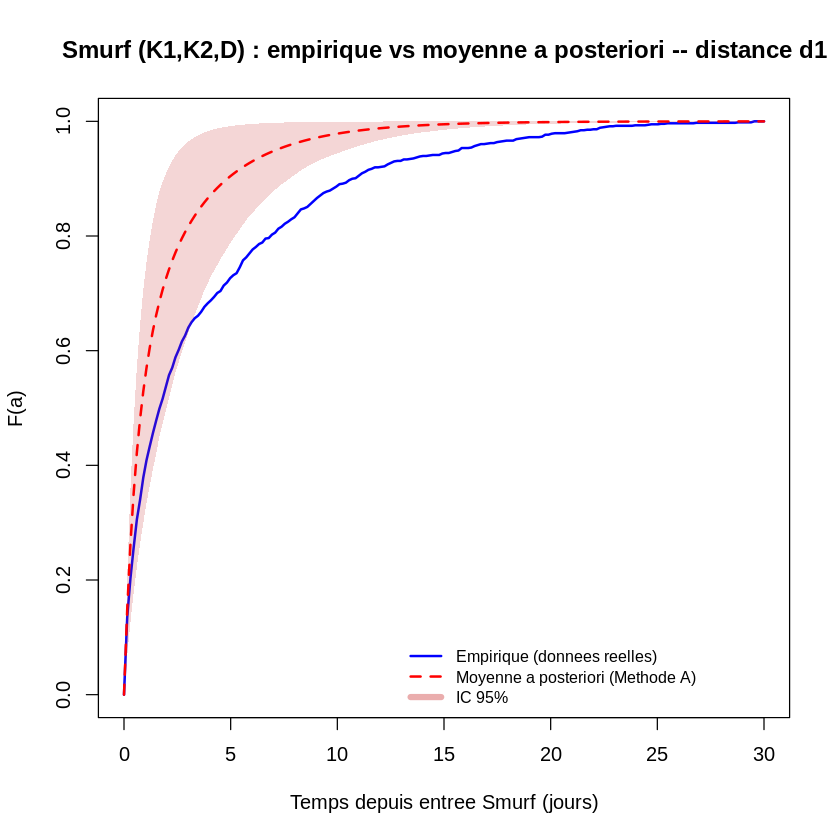

In [ ]:
#################################################################
# COURBE SMURF (K1,K2,D) - DISTANCE D1 - VERSION MINIMALE POUR LE RAPPORT
#################################################################

# 1. CHARGEMENT DES VRAIES DONNEES (adaptez le chemin si besoin)
df <- read.csv("times_exp.txt")
df$Smurf_days <- df$Smurf / 24
df$Death_days <- df$Death / 24


# 2. CHARGEMENT DES PARTICULES K1,K2,D (distance d1)
env_k1k2d <- new.env()
load("ABC_SMC_gen_6_réelle_d1.RData", envir = env_k1k2d)
res_K1K2D <- env_k1k2d$res.new


# 3. FONCTIONS NECESSAIRES

F_S_theo <- function(a_days, K1, K2, D){
  a_h <- a_days * 24
  integrale <- K1*a_h + (K2/D)*(1 - exp(-D*a_h))
  1 - exp(-integrale)
}

fonction_repartition_empirique <- function(echantillon, grille){
  echantillon <- sort(echantillon[!is.na(echantillon)])
  sapply(grille, function(t) mean(echantillon <= t))
}

courbe_moyenne_posteriori <- function(grille, particules, fonction_theo){
  n_part <- nrow(particules)
  mat <- matrix(NA, nrow = n_part, ncol = length(grille))
  for(i in 1:n_part){
    mat[i, ] <- fonction_theo(grille, particules[i,1], particules[i,2], particules[i,3])
  }
  list(
    moyenne = colMeans(mat),
    lower95 = apply(mat, 2, quantile, probs = 0.025),
    upper95 = apply(mat, 2, quantile, probs = 0.975)
  )
}


# 4. CALCUL

t_max <- 30
n_points <- 200
grille <- seq(0, t_max, length.out = n_points)

emp  <- fonction_repartition_empirique(df$Death_days, grille)
post <- courbe_moyenne_posteriori(grille, res_K1K2D, F_S_theo)


# 5. GRAPHIQUE (affichage + sauvegarde)

tracer <- function(){
  plot(grille, emp, type = "l", col = "blue", lwd = 2,
       ylim = c(0,1), xlab = "Temps depuis entree Smurf (jours)", ylab = "F(a)",
       main = "Smurf (K1,K2,D) : empirique vs moyenne a posteriori -- distance d1")
  polygon(c(grille, rev(grille)), c(post$upper95, rev(post$lower95)),
          col = rgb(0.8,0.2,0.2,alpha=0.2), border = NA)
  lines(grille, post$moyenne, col = "red", lwd = 2, lty = 2)
  legend("bottomright",
         legend = c("Empirique (donnees reelles)", "Moyenne a posteriori (Methode A)", "IC 95%"),
         col = c("blue","red", rgb(0.8,0.2,0.2,alpha=0.4)),
         lty = c(1,2,1), lwd = c(2,2,5), bty = "n", cex = 0.8)
}

tracer()   # affichage inline

png("verification_loi_smurf_d1.png", width = 900, height = 650)
tracer()
dev.off()